# Streaming Decoder Visualizations

This notebook visualizes results saved by `save_split_results()` / `load_split_results()`.

Each split is stored in two files:
- `{split}_metadata.parquet` — scalar + list columns (WER, glosses, predictions, segments)
- `{split}_arrays.npz` — per-frame logit arrays (logits, probs, labels, states)

**Cells are organized by visualization type:**
1. Imports & Constants
2. I/O Helpers
3. Color Palette Helpers
4. Plot 1 — Sequence Timeline
5. Plot 2 — Post-bag Confidence Heatmap
6. Plot 3 — WER Distribution
7. Plot 4 — Split Overview Grid
8. Plot 5 — Sign-level Confusion Matrix
9. Convenience — Batch Export All Sequences
10. Run Everything

---
## 1. Imports & Constants

In [2]:
from __future__ import annotations

import json
import os
from typing import Sequence

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Constants — must match the values used in the decoder
# ---------------------------------------------------------------------------

# Directory where the .parquet and .npz result files live
RESULTS_DIR = "./trained_models42/results"

# Frames per second captured by the Leap Motion sensor
LEAP_FPS = 30

# Number of consecutive frames whose votes are majority-pooled before
# committing a label (the "bag" in bag-of-frames decoding)
BAG_SIZE = 5

# Minimum post-bag top-1 probability required to accept a sign prediction
CONFIDENCE_THRESHOLD = 0.35

# Minimum gap between the top-1 sign probability and the background probability;
# if the gap is smaller the frame is treated as background
SIGN_BG_MARGIN = 0.10

# Label string used for the background / no-sign class
BACKGROUND_LABEL = "background"  # change if your project uses a different name

---
## 2. I/O Helpers
Functions to load saved split results from disk and extract per-sequence arrays.

In [3]:
def load_split_results(
    split_name: str,
    results_dir: str = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Reads two files written by save_split_results():
        {slug}_metadata.parquet  — WER scalars, GT glosses, predictions,
                                   emit_regions and gt_segments (as JSON strings)
        {slug}_arrays.npz        — per-frame logit/prob/label/state arrays

    Parameters
    ----------
    split_name  : e.g. "test", "dev_val", "test_(user1)" — must match
                  the slug used when saving
    results_dir : directory containing the parquet / npz files

    Returns
    -------
    df     : DataFrame with all scalars + list columns
    arrays : dict keyed by "{row_idx}__{rec_id}__{field}"
    """
    slug = (
        split_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    print(slug)
    parquet_path = os.path.join(results_dir, f"{slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    def _deserialize_regions(x) -> list[tuple]:
        if not isinstance(x, str):
            return []
        out = []
        for r in json.loads(x):
            if isinstance(r, dict):
                # gt_segments saved as dicts — extract values by key
                out.append((int(r["start_frame"]), int(r["end_frame"]), str(r["label"])))
            elif isinstance(r, (list, tuple)) and len(r) >= 3:
                # emit_regions saved as lists — cast directly
                out.append((int(r[0]), int(r[1]), str(r[2])))
        return out

    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(_deserialize_regions)

    npz    = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(row: pd.Series, arrays: dict) -> dict:
    """
    Extract all per-frame arrays for a single DataFrame row.

    Constructs the key prefix from the row index and recording_id,
    then pulls every stored field from the shared arrays dict.

    Returns
    -------
    dict with keys:
        pre_bag_logits  (T, C) float32  — raw model logits before bag pooling
        post_bag_probs  (T, C) float32  — softmax probs after bag; first
                                          (BAG_SIZE-1) rows are NaN
        frame_indices   (T,)   int32    — original frame numbers
        raw_labels      (T,)   object   — per-frame pre-bag top-1 label string
        voted_labels    (T,)   object   — post-bag majority-vote label string
        raw_conf        (T,)   float32  — pre-bag top-1 confidence
        bg_conf         (T,)   float32  — post-bag background class confidence
        states          (T,)   object   — decoder FSM state string per frame
    """
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {f: arrays.get(f"{prefix}__{f}") for f in fields}


def _safe_segment_tuple(seg):
    """Convert a segment tuple/list/dict to (int start, int end, str label).
    Returns None if the input cannot be safely cast."""
    if isinstance(seg, dict):
        try:
            return (int(seg["start_frame"]), int(seg["end_frame"]), str(seg["label"]))
        except (KeyError, ValueError, TypeError):
            return None
    if isinstance(seg, (tuple, list)) and len(seg) >= 3:
        try:
            return (int(seg[0]), int(seg[1]), str(seg[2]))
        except (ValueError, TypeError):
            pass
    return None

---
## 3. Color Palette Helpers
Builds a stable color mapping from label strings to RGBA tuples. Background is always light grey; sign labels get distinct colors from the tab20 colormap.

In [4]:
def _build_label_colors(
    all_labels: Sequence[str],
    background_label: str = BACKGROUND_LABEL,
    cmap_name: str = "tab20",
) -> dict[str, tuple]:
    """
    Assign a stable, distinct color to every label.

    - Background label is always rendered as light grey so it never
      visually competes with actual sign labels.
    - Sign labels are sorted alphabetically before colors are assigned
      so the mapping is reproducible across calls with different label
      subsets (as long as the full vocabulary is the same).

    Parameters
    ----------
    all_labels       : full set of label strings seen in this context
    background_label : the label name to paint grey
    cmap_name        : matplotlib colormap to sample sign colors from

    Returns
    -------
    dict mapping label string → RGBA tuple
    """
    sign_labels = sorted(set(all_labels) - {background_label})

    # Support both old (get_cmap) and new (colormaps[]) matplotlib APIs
    try:
        cmap = plt.colormaps[cmap_name]
    except AttributeError:
        cmap = plt.cm.get_cmap(cmap_name)

    colors = [cmap(i) for i in range(len(sign_labels))] if sign_labels else []
    color_dict = {lbl: colors[i] for i, lbl in enumerate(sign_labels)}
    color_dict[background_label] = (0.88, 0.88, 0.88, 1.0)  # light grey
    return color_dict

---
## 4. Plot 1 — Sequence Timeline

**What it shows:** A three-row timeline for a single recording.

| Row | Content |
|-----|---------|
| 0 — GT regions | Colored bars spanning the ground-truth segment boundaries, labeled with the gloss |
| 1 — Pre-bag vote | Frame-by-frame color strip of the decoder's top-1 label *before* bag pooling; red dashed lines mark emission events |
| 2 — Confidence curves | Pre-bag and post-bag top-1 confidence over time, background confidence, threshold lines, and blue shading where the FSM is in the IN_SIGN state |

**Use it to:** spot where the model is uncertain, where it transitions correctly vs incorrectly, and how the bag smoothing changes confidence.

In [5]:
def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    label_colors: dict | None = None,
    background_label: str     = BACKGROUND_LABEL,
    figsize: tuple            = (20, 10),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    Five-row timeline for one sequence.

    Row 0 — Ground-truth segmentation regions (colored bars)
    Row 1 — Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 2 — Per-frame post-bag voted label strip (smoothed)
    Row 3 — Pre-bag top-1 probability curve (after softmax)
    Row 4 — Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end, labelled on row 1.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax → top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 5 rows — height ratios 1 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        5, 1, figure=fig,
        height_ratios=[1, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])
    ax3 = fig.add_subplot(gs[3])
    ax4 = fig.add_subplot(gs[4])

    all_axes = [ax0, ax1, ax2, ax3, ax4]

    # Shared x-tick helper — every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper — draw emit regions across a given set of axes
    # Shaded span + dotted start/end lines + label text on ax1 only
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 2: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 3: pre-bag top-1 probability ------------------------------
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 4: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    # Label text placed on ax1 (pre-bag strip) where there's vertical room
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Emit region legend entries
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## Decoding Stage Breakdown (new — does not modify plot_sequence_timeline or plot_wer_distribution)

**What it shows:** one row per stage of the decoding pipeline for a single sequence, so each
stage's effect is directly visible and comparable against ground truth:

1. **Ground truth** — GT segmentation regions (colored bars)
2. **Missing values** — frames where both hands are lost, from the Leap CSV (toggle with
   `show_missing`, on by default)
3. **Window-level predictions before any processing** — raw per-frame pre-bag top-1 label
4. **Raw pre-bag top-1 probability** — the actual confidence value behind row 3's label
   (row 3 only shows *which* class won, not *how sure* the raw window was), with the
   `CONFIDENCE_THRESHOLD` line for reference
5. **Predictions after bag-size aggregation** — post-bag voted label per frame
6. **Final predicted region** — the decoder's emitted sign segments, drawn as GT-style bars
   so they can be visually diffed against the GT row directly (row 0)

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

# Assume BACKGROUND_LABEL, CONFIDENCE_THRESHOLD, get_sequence_arrays,
# _safe_segment_tuple, _build_label_colors are defined elsewhere.


def plot_decoding_stages(
    row: pd.Series,
    arrays: dict,
    csv_path: str | Path | None = None,
    show_missing: bool          = True,
    label_colors: dict | None   = None,
    background_label: str      = BACKGROUND_LABEL,
    figsize: tuple              = (20, 10.5),
    title: str | None           = None,
    save_path: str | None       = None,
) -> plt.Figure:
    """
    Per-sequence view of each decoding stage, one row per stage:

    Row 0 — Ground truth segmentation regions (colored bars)
    Row 1 — Missing values: frames where both hands are lost (red ticks).
             Only drawn when show_missing=True (default) — controlled purely
             by the flag, independent of whether csv_path/data is available.
    Row 2 — Predictions AFTER bag-size aggregation (post-bag voted label
             per frame — smoothed by the bag + confidence gate)
    Row 3 — Final predicted region: the decoder's emitted sign segments,
             drawn as GT-style bars (directly comparable to row 0)

    Pre‑bag (raw window) and raw‑probability rows have been removed.
    """
    seq          = get_sequence_arrays(row, arrays)
    frames       = seq["frame_indices"]
    raw_labels   = seq["raw_labels"]
    voted_labels = seq["voted_labels"]
    raw_conf     = seq["raw_conf"]

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # ---- Missing-value detection (only computed if the row will be shown) ----
    missing_mask = None
    if show_missing and csv_path is not None and Path(csv_path).exists():
        df_csv   = pd.read_csv(csv_path)
        left_ok  = (df_csv["left_confidence"]  > 0) & (df_csv["left_palm_x"]  != 0)
        right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
        missing_mask = ~(left_ok | right_ok)

    # ---- Build color palette (shared across GT row and final-region row) ----
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels |= {reg[2] for reg in emit_regions}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout — one row per stage; pre‑bag rows are omitted.
    # ------------------------------------------------------------------
    row_specs = [("gt", 1.0)]
    if show_missing:
        row_specs.append(("missing", 0.4))
    row_specs += [("post_bag", 1.0), ("final_region", 1.0)]

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        len(row_specs), 1, figure=fig,
        height_ratios=[h for _, h in row_specs],
        hspace=0.12,
    )
    axes = {name: fig.add_subplot(gs[i]) for i, (name, _) in enumerate(row_specs)}
    all_axes = list(axes.values())

    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    def _draw_segment_bar(ax, segments, ylabel):
        if segments:
            for (start, end, label) in segments:
                color = label_colors.get(label, "steelblue")
                ax.barh(0, end - start, left=start, height=0.6,
                        color=color, edgecolor="black", linewidth=0.5)
                cx = (start + end) / 2
                ax.text(cx, 0, label, ha="center", va="center", fontsize=7,
                        fontweight="bold",
                        color="white" if sum(color[:3]) < 1.5 else "black",
                        clip_on=True)
        else:
            ax.text(0.5, 0.5, "No segments available",
                    ha="center", va="center", transform=ax.transAxes, fontsize=9)
        ax.set_yticks([0])
        ax.set_yticklabels([ylabel], fontsize=9)
        ax.set_ylim(-0.5, 0.5)

    def _draw_frame_strip(ax, per_frame_labels, ylabel):
        if per_frame_labels is not None and len(per_frame_labels) == len(frames):
            for i, fi in enumerate(frames):
                label = str(per_frame_labels[i])
                color = label_colors.get(label, "lightgrey")
                ax.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")
        ax.set_yticks([0])
        ax.set_yticklabels([ylabel], fontsize=9)
        ax.set_ylim(-0.5, 0.5)

    # ---- Row: ground truth ---------------------------------------------
    _draw_segment_bar(axes["gt"], gt_segments, "GT")
    _apply_xticks(axes["gt"], show_labels=False)
    axes["gt"].set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row: missing values --------------------------------------------
    if show_missing:
        ax_miss = axes["missing"]
        if missing_mask is not None:
            for f_idx in np.where(missing_mask)[0]:
                ax_miss.axvline(x=f_idx, color="red", alpha=0.8, linewidth=1.5)
        else:
            ax_miss.text(0.5, 0.5, "No CSV provided — missing-frame data unavailable",
                         ha="center", va="center", transform=ax_miss.transAxes,
                         fontsize=8, color="grey")
        ax_miss.set_yticks([0])
        ax_miss.set_yticklabels(["Missing"], fontsize=9, color="red")
        ax_miss.set_ylim(-0.5, 0.5)
        for spine in ("left", "right", "top", "bottom"):
            ax_miss.spines[spine].set_visible(False)
        ax_miss.tick_params(axis="y", left=False)
        _apply_xticks(ax_miss, show_labels=False)

    # ---- Row: predictions AFTER bag-size aggregation --------------------
    _draw_frame_strip(axes["post_bag"], voted_labels, "Post-bag\n(voted)")
    _apply_xticks(axes["post_bag"], show_labels=False)

    # ---- Row: final predicted region (decoder's emitted segments) ------
    _draw_segment_bar(axes["final_region"], emit_regions, "Final\nregion")
    axes["final_region"].set_xlabel("Frame index", fontsize=9)
    _apply_xticks(axes["final_region"], show_labels=True)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    if show_missing:
        handles.append(Line2D([0], [0], color="red", linewidth=2.0, label="Missing data"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.03),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig

In [7]:
def plot_wer_distribution(
    df: pd.DataFrame,
    split_name: str       = "",
    figsize: tuple        = (14, 5),
    top_n_worst: int      = 10,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Two-panel WER distribution plot for an entire split.

    Left  — Histogram of WER values with mean / median reference lines
             and sample-count + std annotation.
    Right — Per-user box plot (one box per unique user).
             If only one user is present, falls back to a per-sequence
             scatter plot so the panel is never empty.

    Also prints the top_n_worst sequences ranked by WER (descending).

    Parameters
    ----------
    df          : DataFrame returned by load_split_results()
    split_name  : shown in the figure suptitle
    top_n_worst : how many worst-WER sequences to print (default 10)
    save_path   : if given, saves figure here instead of displaying inline

    Note on double-display
    ----------------------
    plt.show() is intentionally NOT called here. Jupyter auto-renders the
    returned Figure object, so calling plt.show() would cause it to appear
    twice. When save_path is set, plt.close() is called to free memory.
    """
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(f"WER Distribution — {split_name}", fontsize=12)

    wer = df["wer"].dropna().values

    # ---- Left: WER histogram ------------------------------------------
    ax_hist.hist(wer, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax_hist.axvline(wer.mean(),     color="red",    linewidth=1.5, linestyle="--",
                    label=f"Mean   {wer.mean():.3f}")
    ax_hist.axvline(np.median(wer), color="orange", linewidth=1.5, linestyle="--",
                    label=f"Median {np.median(wer):.3f}")
    ax_hist.set_xlabel("WER",   fontsize=9)
    ax_hist.set_ylabel("Count", fontsize=9)
    ax_hist.set_title("WER histogram", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.set_xlim(0, max(1.0, wer.max() + 0.05))
    # Std + sample count in the top-right corner
    ax_hist.text(
        0.98, 0.97, f"n={len(wer)}\nstd={wer.std():.3f}",
        ha="right", va="top", transform=ax_hist.transAxes,
        fontsize=8, color="grey",
    )

    # ---- Right: per-user box plot (or scatter for single-user splits) --
    if "user" in df.columns and df["user"].nunique() > 1:
        users     = sorted(df["user"].unique())
        user_wers = [df.loc[df["user"] == u, "wer"].values for u in users]
        bp = ax_box.boxplot(
            user_wers, labels=users, patch_artist=True,
            medianprops=dict(color="red", linewidth=1.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor("steelblue")
            patch.set_alpha(0.5)
        ax_box.set_xlabel("User", fontsize=9)
        ax_box.set_ylabel("WER",  fontsize=9)
        ax_box.set_title("WER by user", fontsize=10)
        ax_box.tick_params(axis="x", rotation=30)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))
    else:
        # Single user: show per-sequence scatter instead
        ax_box.scatter(df["sample_idx"], df["wer"],
                       color="steelblue", s=25, alpha=0.7)
        ax_box.set_xlabel("Sequence index", fontsize=9)
        ax_box.set_ylabel("WER",            fontsize=9)
        ax_box.set_title("WER per sequence", fontsize=10)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))

    # ---- Print top-N worst sequences ----------------------------------
    # Sort by WER descending; ties keep their original DataFrame order.
    # Prints: rank, recording_id, WER, user (if present), GT, prediction.
    n_to_show = min(top_n_worst, len(df))
    worst     = df.nlargest(n_to_show, "wer")

    print(f"\n{'='*60}")
    print(f"  Top {n_to_show} worst sequences — {split_name}")
    print(f"{'='*60}")
    for rank, (_, row) in enumerate(worst.iterrows(), start=1):
        rec_id  = row.get("recording_id", "—")
        wer_val = float(row["wer"])
        gt      = row.get("ground_truth", "—")
        pred    = row.get("prediction",   "—")
        user    = f"  user={row['user']}" if "user" in row and pd.notna(row["user"]) else ""
        print(f"  #{rank:<3} WER={wer_val:.3f}{user}")
        print(f"       id  : {rec_id}")
        print(f"       GT  : {gt}")
        print(f"       pred: {pred}")
        print()
    print(f"{'='*60}\n")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
        plt.close(fig)  # free memory; no inline display needed when saving

    # No plt.show() — Jupyter renders the returned Figure automatically.
    # Calling plt.show() here would cause the plot to appear twice.
    return fig

---
## 8. Plot 5 — Sign-level Confusion Matrix

**What it shows:** A matrix of GT signs (rows) vs predicted signs (cols), built by aligning `emit_regions` with `gt_segments`.

**Alignment strategy:**
- For each GT segment, find the emission whose midpoint falls inside it → that's the prediction.
- Unmatched GT segments → **deletions** (reported in title)
- Unmatched emissions → **insertions** (reported in title)

**Use it to:** identify which pairs of signs are systematically confused, and quantify deletion vs insertion error modes.

---
## 6. Plot 3 — WER Distribution

**What it shows:** A two-panel summary of Word Error Rate across a whole split.

| Panel | Content |
|-------|---------|
| Left — Histogram | Distribution of WER values; mean (red) and median (orange) dashed lines; std annotated |
| Right — Box plot | Per-user WER spread (or per-sequence scatter if only one user) |

**Use it to:** quickly identify whether errors are concentrated in specific users or spread uniformly, and benchmark overall decoder quality.

In [8]:
def plot_confusion_from_emissions(
    df: pd.DataFrame,
    background_label: str = BACKGROUND_LABEL,
    figsize: tuple        = (12, 10),
    normalize: bool       = True,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Sign-level confusion matrix built by aligning emit_regions with gt_segments.

    Alignment: for each GT segment, the emitted sign whose region midpoint
    falls inside the GT segment is treated as the prediction.
    Unmatched GT segments  → deletion  (tallied; shown in the title)
    Unmatched emissions    → insertion (tallied; shown in the title)

    Parameters
    ----------
    normalize : if True, each row is divided by (row_hits + row_deletions)
                so cells show per-class recall (row sums ≤ 1).
                if False, raw counts are shown.
    save_path : if given, saves figure here instead of displaying inline
    """
    # Gather every sign label that appears in predictions or GT
    all_signs = set()
    for _, row in df.iterrows():
        for seg in row.get("gt_segments", []):
            t = _safe_segment_tuple(seg)
            if t and t[2] != background_label:
                all_signs.add(t[2])
        for reg in row.get("emit_regions", []):
            t = _safe_segment_tuple(reg)
            if t and t[2] != background_label:
                all_signs.add(t[2])

    labels     = sorted(all_signs)
    label_to_i = {l: i for i, l in enumerate(labels)}
    n          = len(labels)

    if n == 0:
        print("No sign labels found in emit_regions / gt_segments.")
        return None

    # Accumulate hits, deletions, and insertions across all sequences
    conf_matrix = np.zeros((n, n), dtype=np.float32)   # [gt_i, pred_i]
    deletions   = np.zeros(n, dtype=np.float32)         # gt sign not emitted
    insertions  = 0                                     # emission with no GT match

    for _, row in df.iterrows():
        gt_segs   = [_safe_segment_tuple(s) for s in row.get("gt_segments",  []) if _safe_segment_tuple(s)]
        gt_segs   = [s for s in gt_segs   if s[2] != background_label]
        emit_regs = [_safe_segment_tuple(r) for r in row.get("emit_regions", []) if _safe_segment_tuple(r)]
        emit_regs = [r for r in emit_regs if r[2] != background_label]

        matched_emit = set()

        for (gs, ge, gl) in gt_segs:
            gt_i = label_to_i.get(gl)
            if gt_i is None:
                continue

            # Find the first emission whose midpoint is within this GT segment
            match = None
            for eidx, (es, ee, el) in enumerate(emit_regs):
                if gs <= (es + ee) / 2 <= ge:
                    match = (eidx, el)
                    break

            if match is not None:
                eidx, el = match
                pred_i   = label_to_i.get(el)
                matched_emit.add(eidx)
                if pred_i is not None:
                    conf_matrix[gt_i, pred_i] += 1
            else:
                # No emission found inside this GT segment → deletion
                deletions[gt_i] += 1

        # Any emission not matched to a GT segment → insertion
        insertions += sum(1 for eidx in range(len(emit_regs)) if eidx not in matched_emit)

    # Optionally normalise each row to give per-class recall
    if normalize:
        row_sums    = conf_matrix.sum(axis=1, keepdims=True) + deletions[:, np.newaxis]
        row_sums    = np.where(row_sums == 0, 1, row_sums)   # avoid div-by-zero
        plot_matrix = conf_matrix / row_sums
    else:
        plot_matrix = conf_matrix

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    im = ax.imshow(plot_matrix, cmap="Blues",
                   vmin=0, vmax=1 if normalize else None)

    # Annotate each cell with value (skip zeros to reduce clutter)
    thresh = plot_matrix.max() / 2.0
    for i in range(n):
        for j in range(n):
            val = plot_matrix[i, j]
            if val > 0:
                ax.text(
                    j, i,
                    f"{val:.2f}" if normalize else f"{int(val)}",
                    ha="center", va="center", fontsize=7,
                    color="white" if val > thresh else "black",
                )

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted label",    fontsize=9)
    ax.set_ylabel("Ground truth label", fontsize=9)
    ax.set_title(
        f"Sign confusion matrix ({'normalized recall' if normalize else 'counts'})\n"
        f"Total deletions: {int(deletions.sum())}  |  Total insertions: {insertions}",
        fontsize=10,
    )

    plt.colorbar(im, ax=ax, label="Recall" if normalize else "Count",
                 fraction=0.03, pad=0.02)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 10. Run Everything

Edit the paths and flags below, then run this cell to execute all visualizations in one go.

In [9]:
# ============================================================
# Configuration — edit these before running
# ============================================================

def get_index(df, sequence_id: str):
	return df[test_df['recording_id'] == sequence_id].index[0]


# {class_index: label_string} — must match the mapping used during training.
# Replace with your actual vocabulary dict.
id_to_label = {
    0: "AUGUST",
    1: "BIG",
    2: "BIRD",
    3: "BOAT",
    4: "COME",
    5: "DRIVER",
    6: "FARMING",
    7: "FEBRUARY",
    8: "GO",
    9: "GREETINGS",
    10: "OUR",
    11: "READ",
    12: "SMALL",
    13: "TIGER",
    14: "TRAIN",
    15: "UGLY",
    16: "VAN",
    17: "WHAT",
    18: "WHICH",
    19: "WRITE",
    20: "background",
}

# Splits to load (filenames must exist in RESULTS_DIR)
TEST_SPLIT = "test_user2_20260706t151946z"
VAL_SPLIT  = "val_user2_20260706t151946z"


# ============================================================
# Load splits
# ============================================================
test_df, test_arrays = load_split_results(TEST_SPLIT)
val_df,  val_arrays  = load_split_results(VAL_SPLIT)

print(f"Test split : {len(test_df)} sequences, mean WER={test_df['wer'].mean():.3f}")
print(f"Val  split : {len(val_df)}  sequences, mean WER={val_df['wer'].mean():.3f}")

test_user2_20260706t151946z
val_user2_20260706t151946z
Test split : 73 sequences, mean WER=0.045
Val  split : 33  sequences, mean WER=0.010


In [10]:
test_df['wer'].median()

0.0

In [11]:
test_df.iloc[0]

sample_idx                                                                1
split                                                          Test (user2)
user                                                                  user2
recording_id                                                       P2_S7_R4
num_frames                                                              600
missing_ratio                                                           0.0
gt_len                                                                    3
pred_len                                                                  3
raw_len                                                                 571
wer                                                                     0.0
stream_mode                                                  thct_net_batch
stream_delay_frames                                                       0
num_stream_predictions                                                  571
first_predic

In [12]:
test_df['wer'].mean()

0.04452054794520548

In [13]:
from pathlib import Path

def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    csv_path: str | Path | None = None,
    label_colors: dict | None = None,
    background_label: str     = "background",
    figsize: tuple            = (20, 11),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    [ignoring loop detection]
    Six-row timeline for one sequence.

    Row 0 - Ground-truth segmentation regions (colored bars)
    Row 1 - Missing frames (red blocks where both hands are lost)
    Row 2 - Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 3 - Per-frame post-bag voted label strip (smoothed)
    Row 4 - Pre-bag top-1 probability curve (after softmax)
    Row 5 - Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax -> top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # ---- Missing Frame Calculation -----------------------------------
    missing_mask = None
    if csv_path is not None and Path(csv_path).exists():
        df_csv = pd.read_csv(csv_path)
        left_ok = (df_csv["left_confidence"] > 0) & (df_csv["left_palm_x"] != 0)
        right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
        missing_mask = ~(left_ok | right_ok)

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 6 rows - height ratios 1 : 0.4 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        6, 1, figure=fig,
        height_ratios=[1, 0.4, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax_miss = fig.add_subplot(gs[1])
    ax1 = fig.add_subplot(gs[2])
    ax2 = fig.add_subplot(gs[3])
    ax3 = fig.add_subplot(gs[4])
    ax4 = fig.add_subplot(gs[5])

    all_axes = [ax0, ax_miss, ax1, ax2, ax3, ax4]

    # Shared x-tick helper - every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper - draw emit regions across a given set of axes
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: Missing Frames -----------------------------------------
    if missing_mask is not None:
        missing_indices = np.where(missing_mask)[0]
        # Draw red lines for every missing frame
        for f_idx in missing_indices:
            ax_miss.axvline(x=f_idx, color='red', alpha=0.8, linewidth=1.5)

    ax_miss.set_yticks([0])
    ax_miss.set_yticklabels(["Missing"], fontsize=9, color="red")
    ax_miss.set_ylim(-0.5, 0.5)
    # Remove horizontal bar/grid line at y=0 to make vertical red lines pop
    ax_miss.spines['left'].set_visible(False)
    ax_miss.spines['right'].set_visible(False)
    ax_miss.spines['top'].set_visible(False)
    ax_miss.spines['bottom'].set_visible(False)
    ax_miss.tick_params(axis='y', left=False)
    _apply_xticks(ax_miss, show_labels=False)

    # ---- Row 2: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 3: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 4: pre-bag top-1 probability ------------------------------
    # Use CONFIDENCE_THRESHOLD directly from config or pass it as an argument.
    # Assuming CONFIDENCE_THRESHOLD is defined in scope
    CONFIDENCE_THRESHOLD = 0.35 # Fallback if not defined
    try:
        from config import CONFIDENCE_THRESHOLD
    except:
        pass
        
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 5: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Missing frames legend entry
    handles.append(Line2D([0], [0], color="red", linewidth=2.0, label="Missing Data"))
    
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig


### Example usage — `plot_sequence_timeline`

```
plot_sequence_timeline(
    row,                # one row from load_split_results()'s DataFrame, e.g. test_df.iloc[i]
    arrays,              # the matching arrays dict, e.g. test_arrays
    csv_path=None,       # optional: raw Leap CSV path -> enables the "Missing frames" row
    label_colors=None,   # optional: reuse a color mapping from _build_label_colors(...)
    background_label=BACKGROUND_LABEL,
    figsize=(20, 11),
    title=None,          # optional: overrides the auto-generated title
    save_path=None,      # optional: if given, saves to disk instead of displaying inline
)
```

Pick a sequence by its `recording_id` via `get_index(df, sequence_id)`, then call it directly.
The cell below builds `csv_path` from the raw dataset so the "Missing frames" row is populated;
the cell after that shows the minimal call with `csv_path=None` (the row just stays empty).

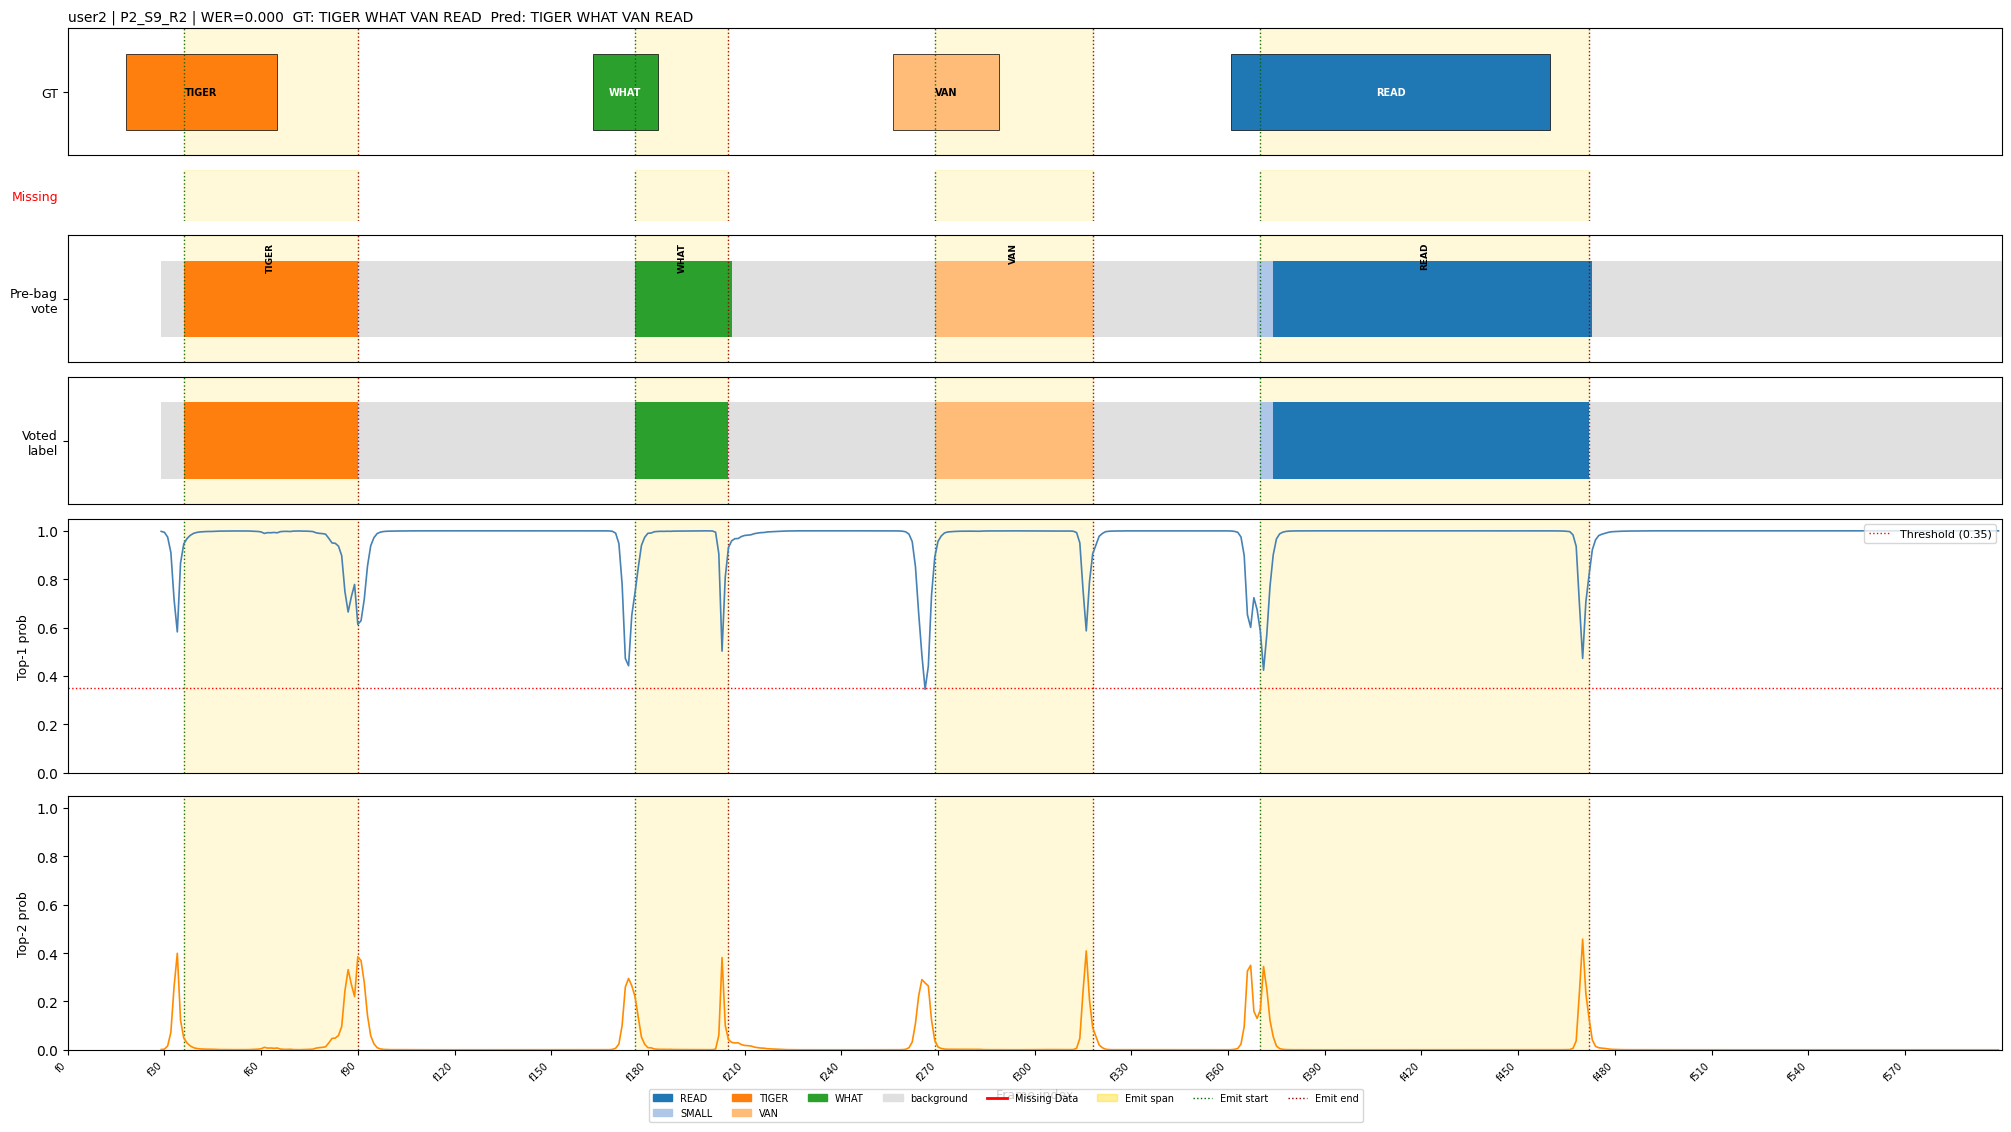

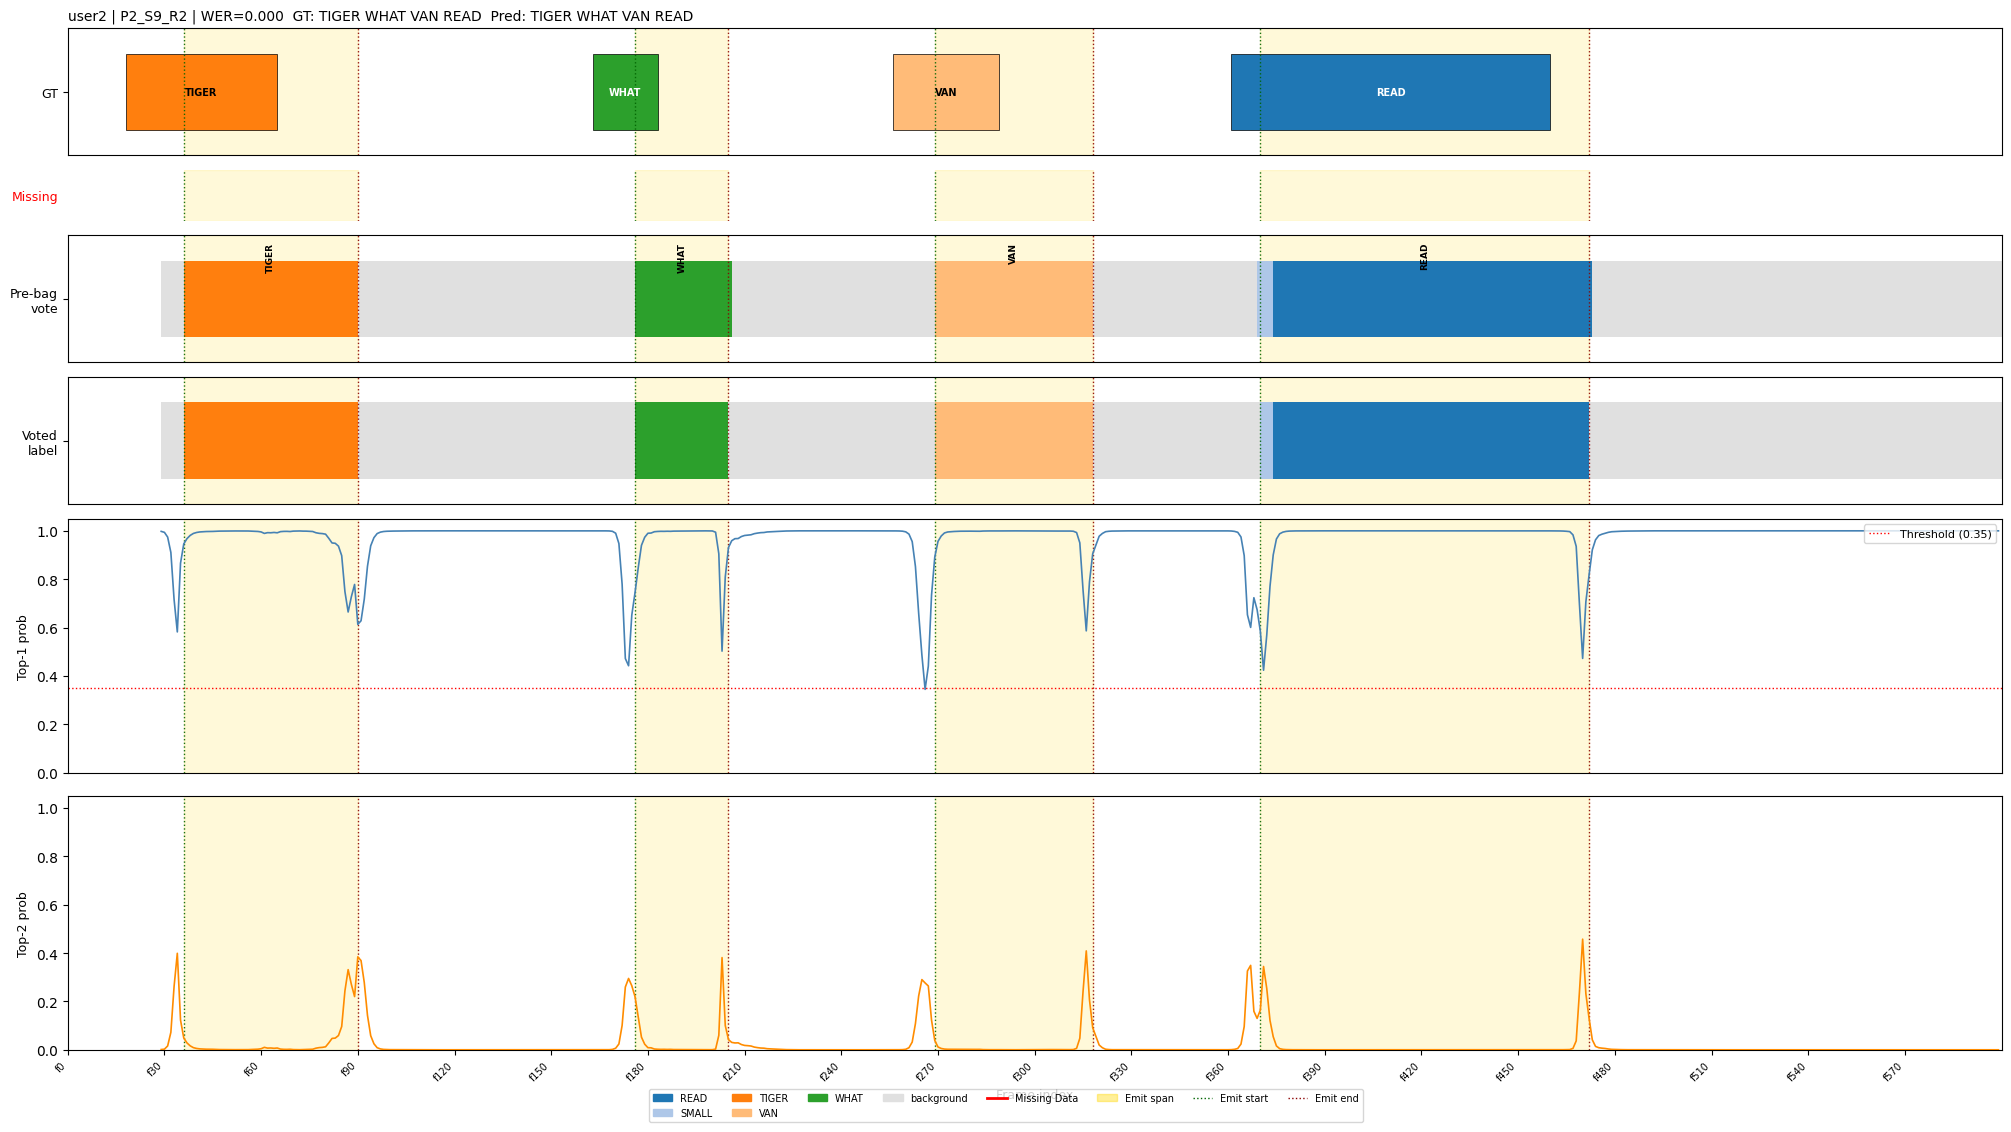

In [14]:
sequence_id = "P2_S9_R2"
user = "user1"
row = test_df.iloc[get_index(test_df, sequence_id)]

# Assuming the base dataset path. You might need to adjust this depending on the notebook's relative path
dataset_root = Path(f"c:/Shoab/Thesis/Experiments/dataset/")
user = row.get('user')  # Assuming this gets you "user1"
csv_path = dataset_root / user / "leap_data" / f"{sequence_id}.csv"

plot_sequence_timeline(row, test_arrays, csv_path=csv_path)

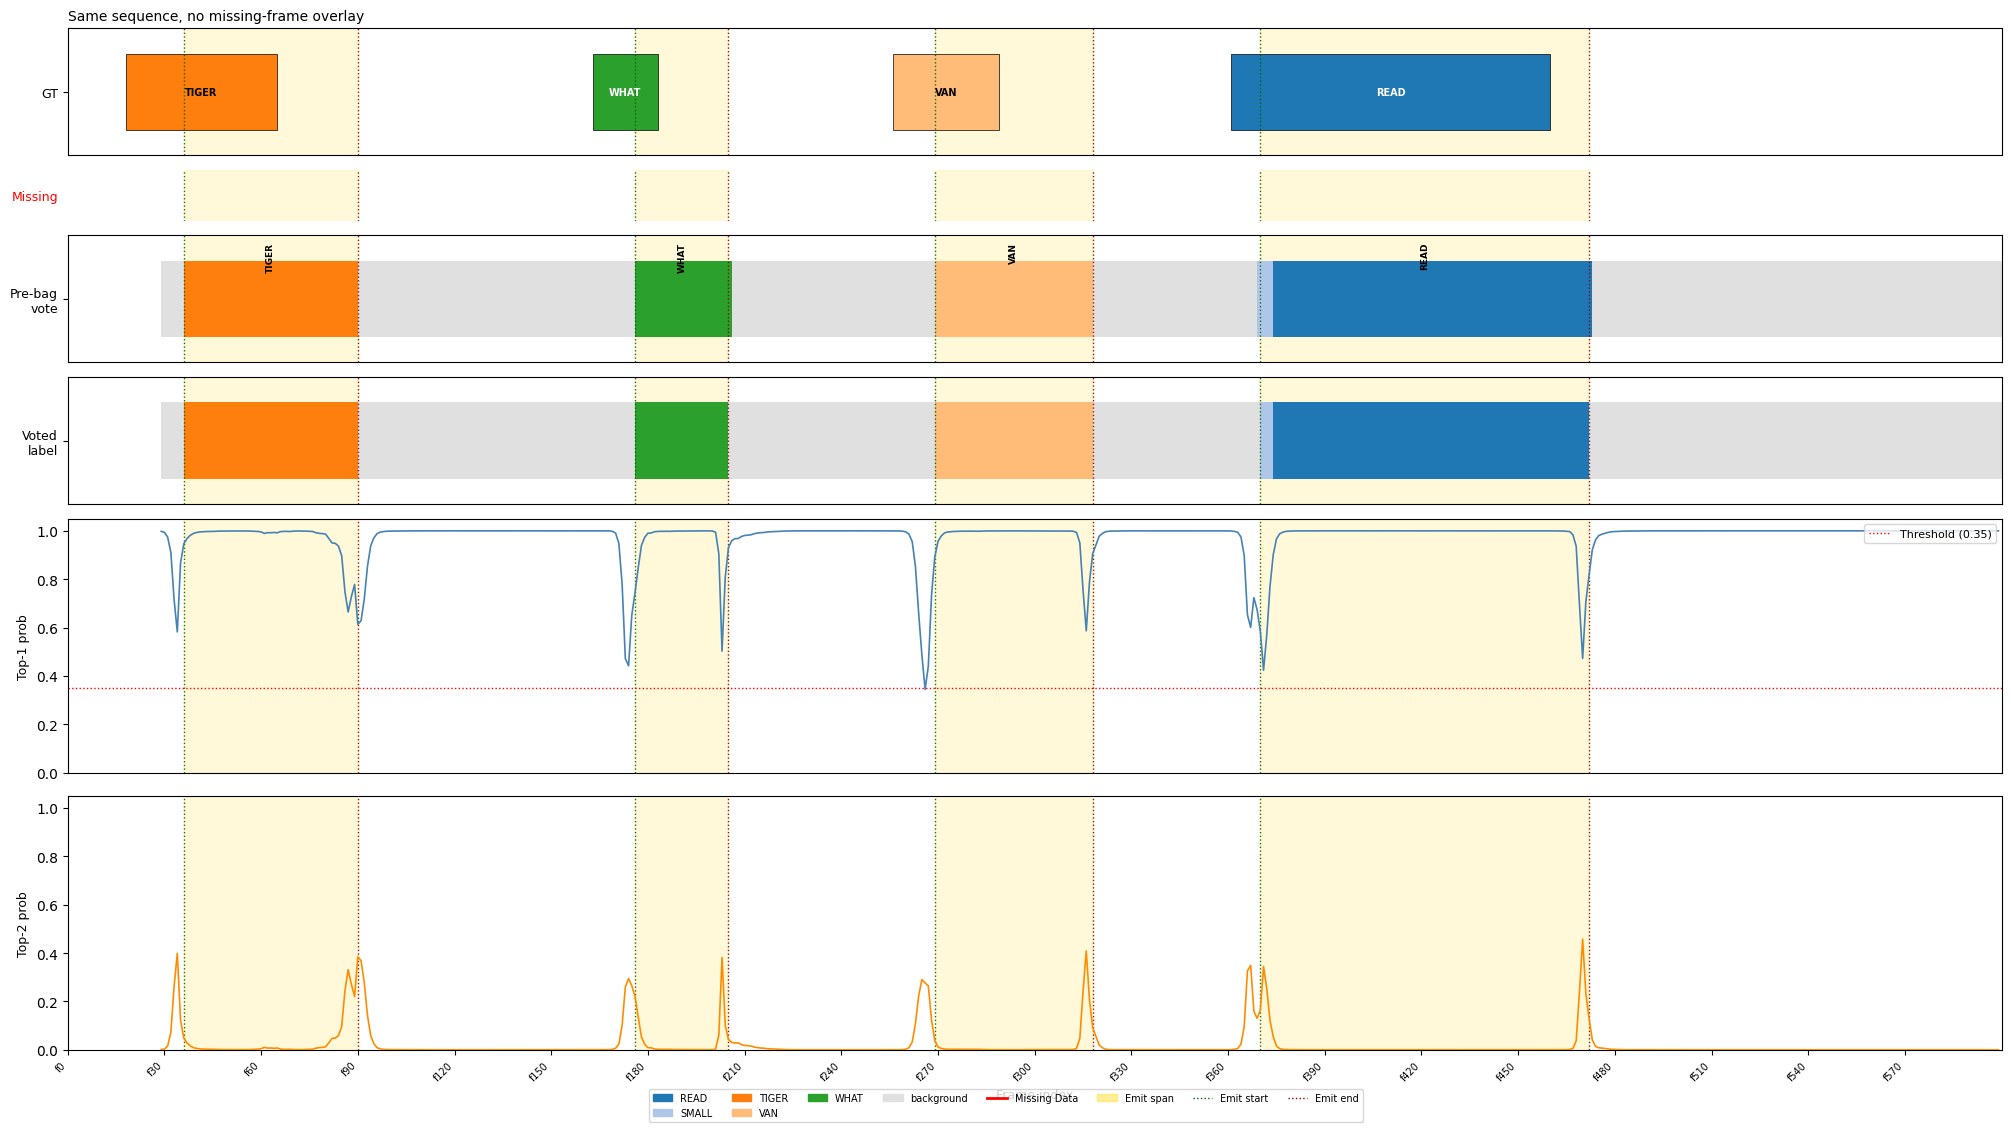

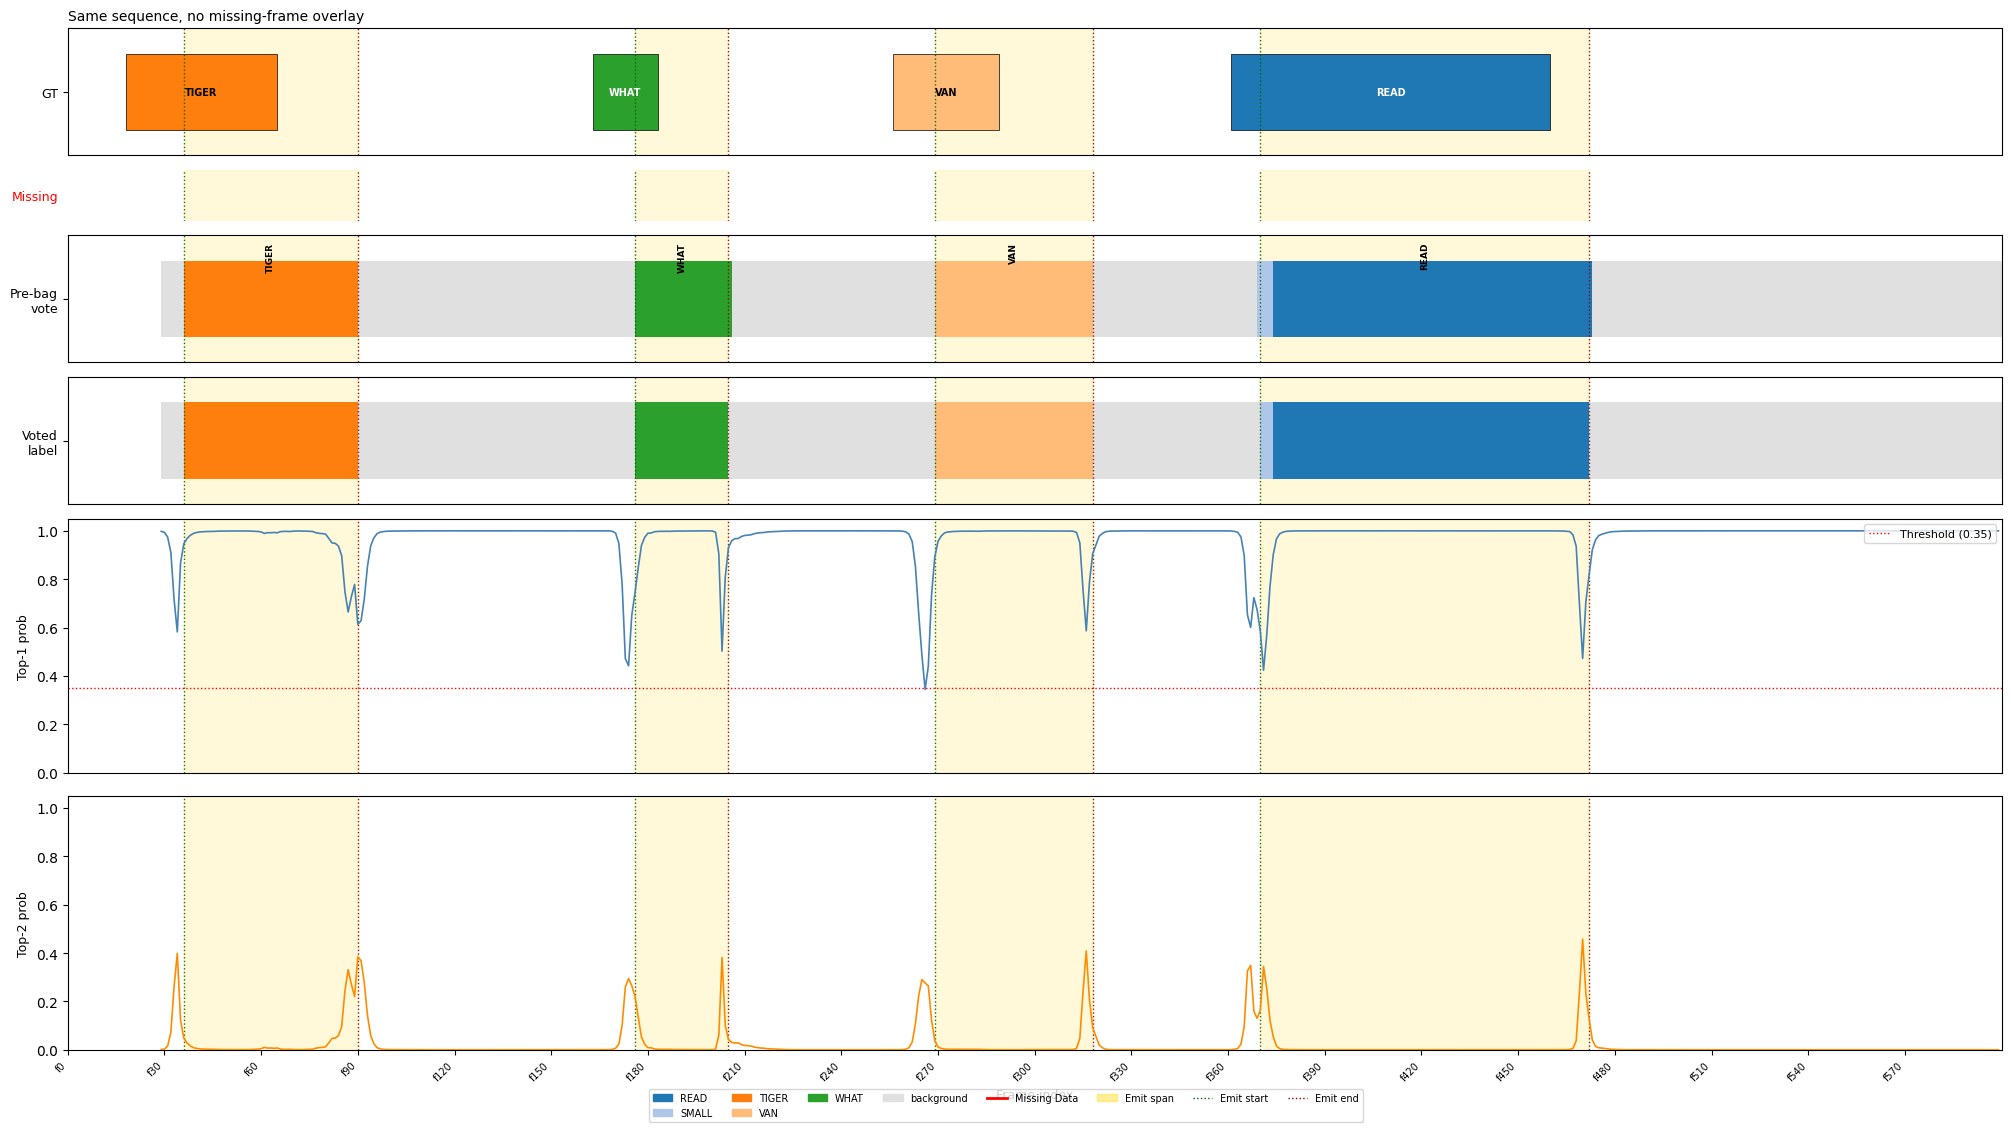

In [15]:
# Minimal call — no csv_path, so the "Missing frames" row stays empty
plot_sequence_timeline(row, test_arrays, csv_path=None,
                       title="Same sequence, no missing-frame overlay")


### Example usage — `plot_decoding_stages`

```
plot_decoding_stages(
    row,                 # one row from load_split_results()'s DataFrame, e.g. test_df.iloc[i]
    arrays,              # the matching arrays dict, e.g. test_arrays
    csv_path=None,       # optional: raw Leap CSV path -> enables the "Missing values" row
    show_missing=True,   # toggle the missing-values row on/off entirely (default True)
    label_colors=None,
    background_label=BACKGROUND_LABEL,
    figsize=(20, 10.5),
    title=None,
    save_path=None,      # optional: if given, saves to disk instead of displaying inline
)
```

Shows GT vs. missing values vs. pre-bag (raw label) vs. pre-bag top-1 probability vs.
post-bag (voted) vs. final predicted region, one row each — useful for spotting exactly
which stage a wrong or missed prediction originates from, and whether it was a low-confidence
call in the first place.

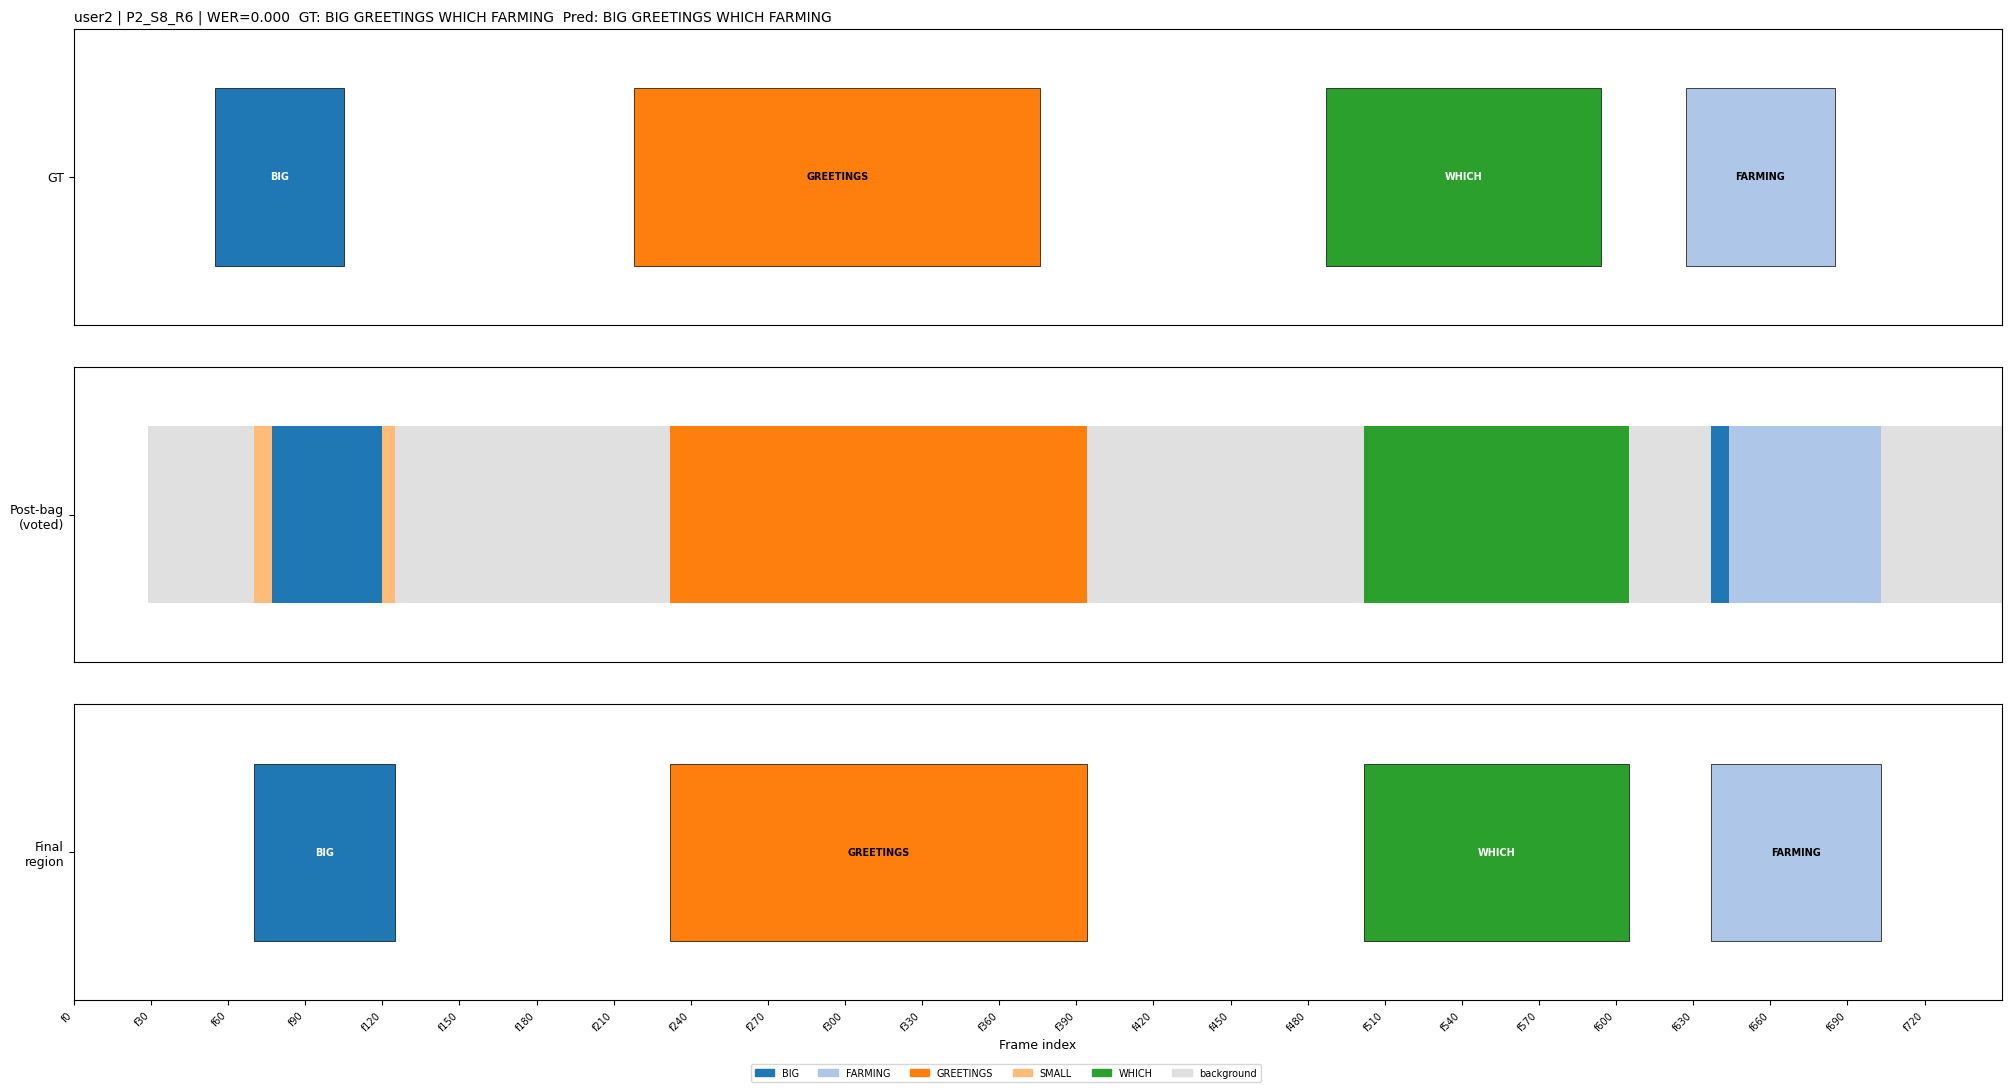

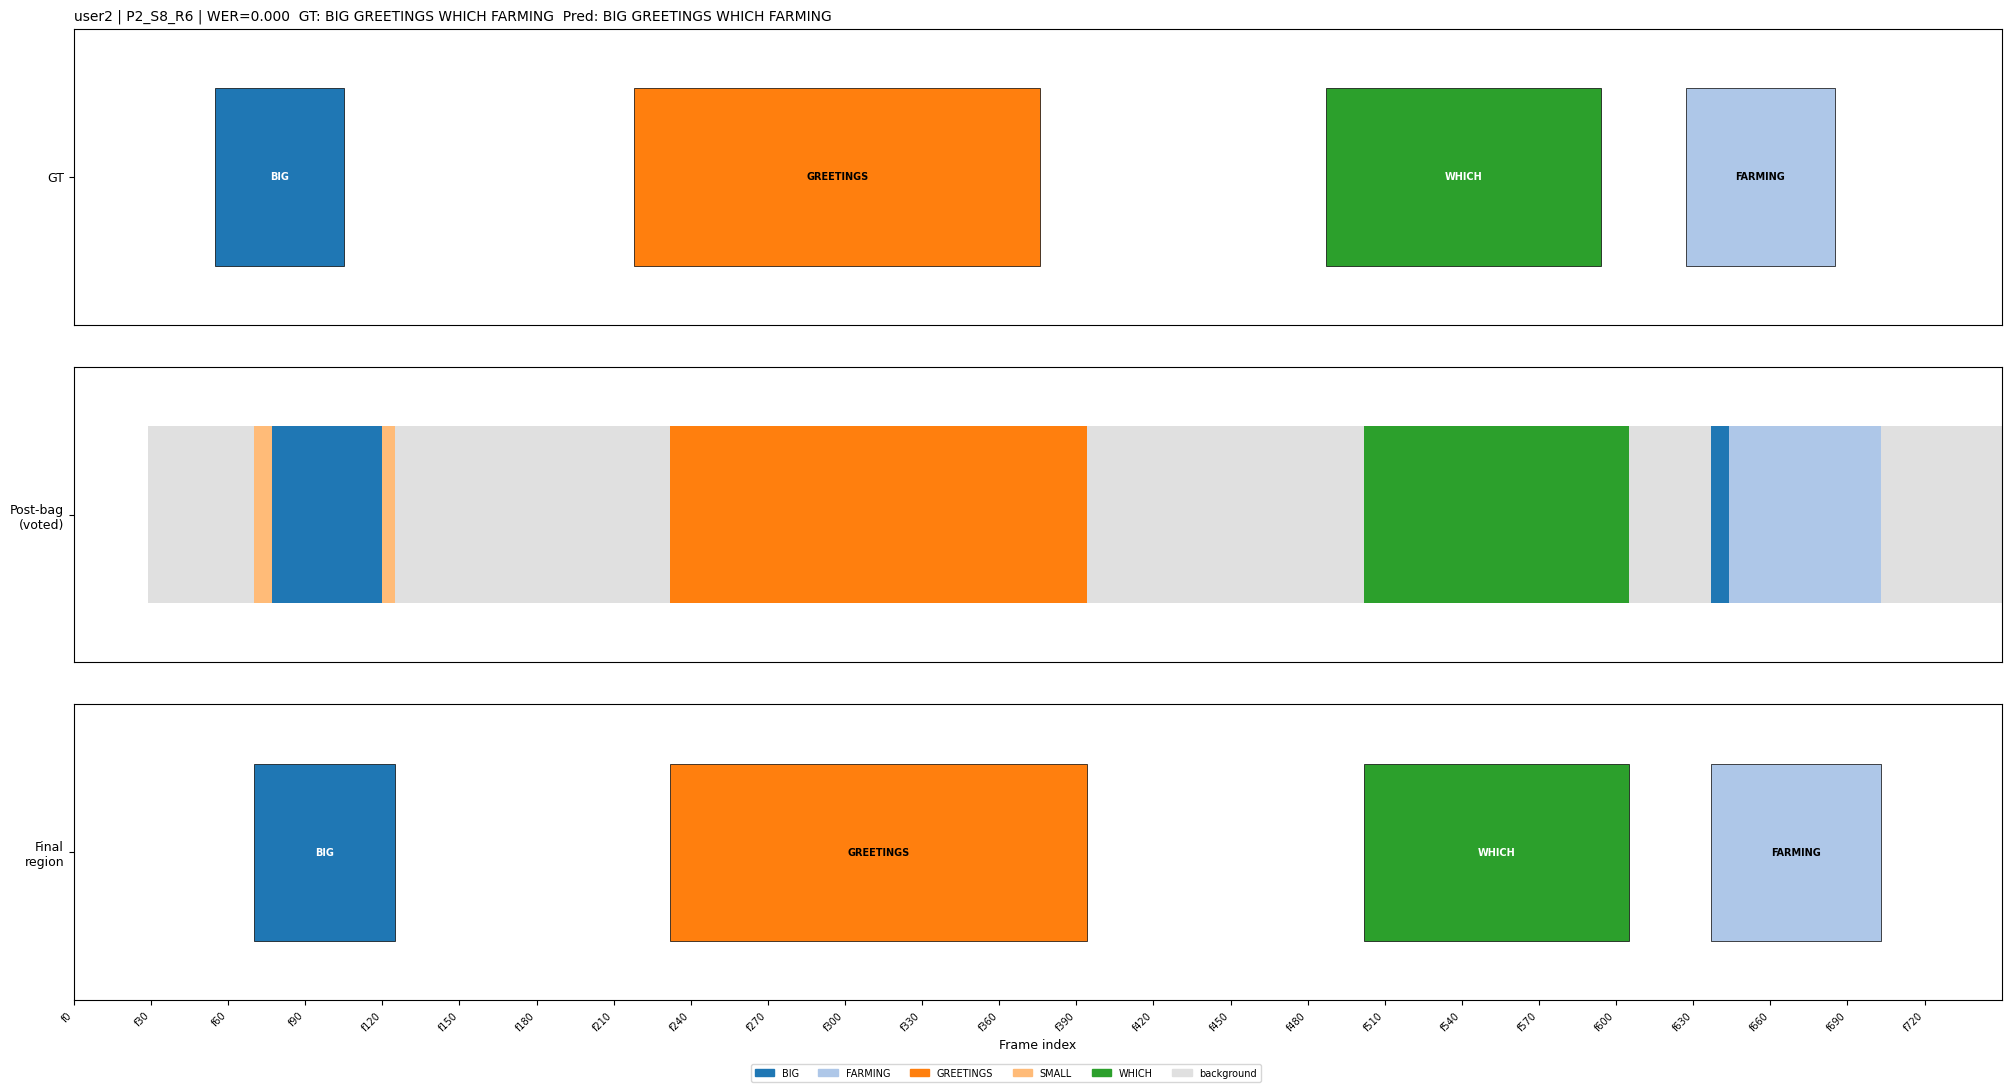

In [16]:
sequence_id = "P2_S8_R6"

row = test_df.iloc[get_index(test_df, sequence_id)]

dataset_root = Path("c:/Shoab/Thesis/Experiments/dataset/")
csv_path = dataset_root / row["user"] / "leap_data" / f"{sequence_id}.csv"

plot_decoding_stages(row, test_arrays, csv_path=csv_path, show_missing=False)



  Top 10 worst sequences — Test
  #1   WER=0.250  user=user2
       id  : P2_S8_R2
       GT  : BIG GREETINGS WHICH FARMING
       pred: BIG BIG GREETINGS WHICH FARMING

  #2   WER=0.250  user=user2
       id  : P2_S11_R2
       GT  : GO UGLY WRITE AUGUST
       pred: COME UGLY WRITE AUGUST

  #3   WER=0.250  user=user2
       id  : P2_S5_R1
       GT  : BIRD WHAT DRIVER GREETINGS
       pred: WHAT DRIVER GREETINGS

  #4   WER=0.250  user=user2
       id  : P2_S1_R3
       GT  : GO READ OUR COME
       pred: GO READ OUR OUR

  #5   WER=0.250  user=user2
       id  : P2_S8_R4
       GT  : BIG GREETINGS WHICH FARMING
       pred: SMALL GREETINGS WHICH FARMING

  #6   WER=0.250  user=user2
       id  : P2_S1_R1
       GT  : GO READ OUR COME
       pred: COME READ OUR COME

  #7   WER=0.250  user=user2
       id  : P2_S5_R2
       GT  : BIRD WHAT DRIVER GREETINGS
       pred: WHAT DRIVER GREETINGS

  #8   WER=0.250  user=user2
       id  : P2_S8_R3
       GT  : BIG GREETINGS WHICH FARMING

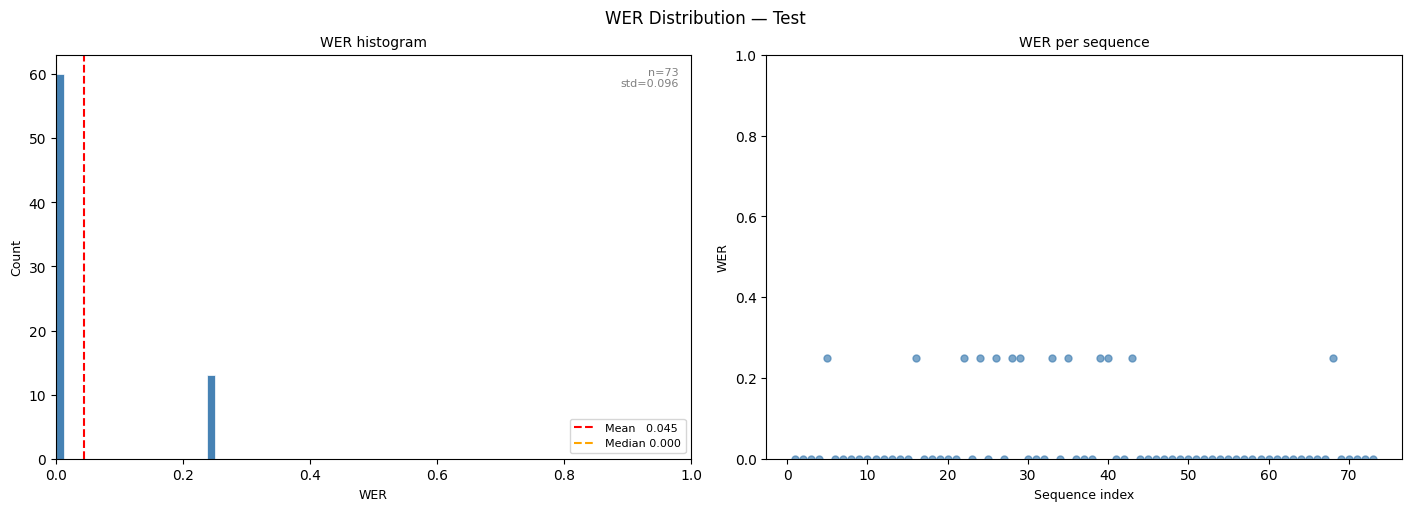

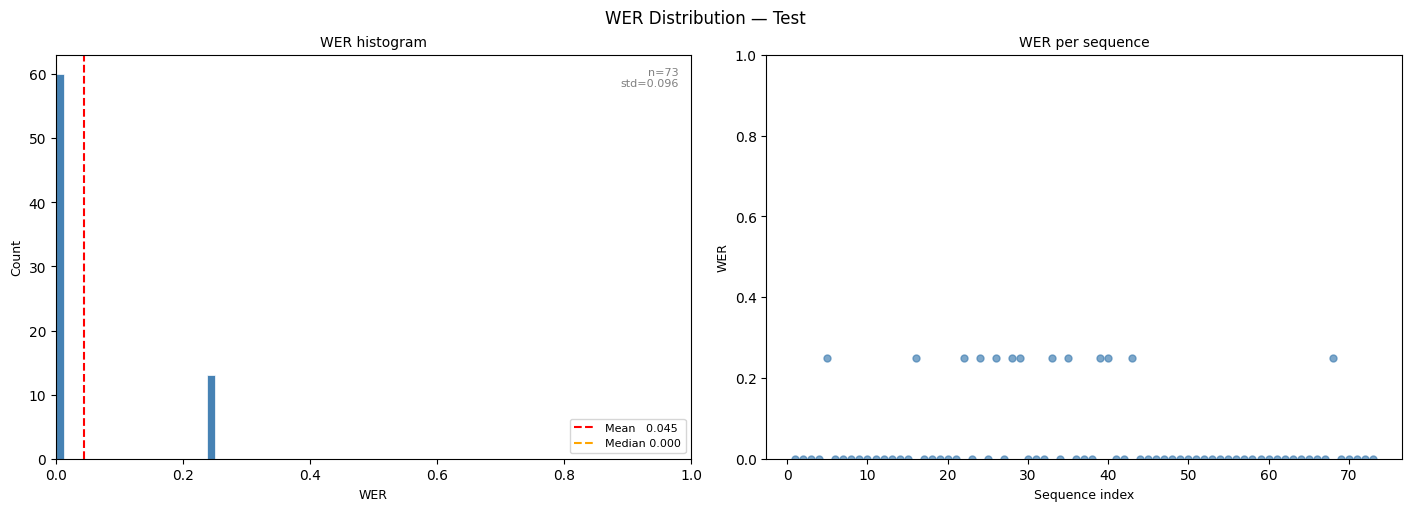

In [17]:
# ============================================================
# Plot 3 — WER distribution for the test split
# ============================================================
plot_wer_distribution(test_df, split_name="Test", top_n_worst=10)

In [18]:
# Additional decoder constants not already defined in the Imports & Constants cell above
# (BAG_SIZE, CONFIDENCE_THRESHOLD, SIGN_BG_MARGIN, id_to_label, BACKGROUND_LABEL are defined there)
BAG_AGGREGATION = "mean"
MIN_SIGN_MS     = 500
MIN_SIGN_FRAMES = max(1, round(MIN_SIGN_MS / 1000 * LEAP_FPS))

label_to_id = {v: k for k, v in id_to_label.items()}


In [19]:
from collections import Counter, deque

# ---------------------------------------------------------------------------
# Bag aggregator + streaming decoder — ported verbatim from decoder.py so it can
# be edited in place here without touching the project's .py sources.
#
# CAUTION: this is the core inference engine. Any changes here directly affect
# WER / streaming metrics results.
# ---------------------------------------------------------------------------

class _BagAggregator:
    """
    Causal sliding bag over raw logits.

    Why logits and not probs:
        Averaging in logit space is equivalent to a product-of-experts,
        which is sharper and more discriminative than averaging softmax probs.
        Converting to probs happens once after aggregation.

    Modes
    -----
    mean      : arithmetic mean of per-window probs after softmax
    max       : element-wise max of per-window probs
    attention : recency-weighted mean, most recent window weighted highest
    """

    def __init__(self, bag_size: int, aggregation: str, num_classes: int):
        self.bag_size    = max(1, int(bag_size))
        self.aggregation = aggregation
        self.num_classes = num_classes
        self._buffer     = deque(maxlen=self.bag_size)

    def update(self, logits: np.ndarray):
        """
        Push one logit vector and return aggregated probs.

        Returns None until bag is full (first bag_size frames are skipped).
        """
        self._buffer.append(logits.copy())

        if len(self._buffer) < self.bag_size:
            return None

        bag         = np.stack(self._buffer, axis=0)           # (bag_size, C)
        bag_shifted = bag - bag.max(axis=-1, keepdims=True)
        exp_bag     = np.exp(bag_shifted)
        probs       = exp_bag / exp_bag.sum(axis=-1, keepdims=True)  # (bag_size, C)

        if self.aggregation == "mean":
            return probs.mean(axis=0)

        if self.aggregation == "max":
            return probs.max(axis=0)

        if self.aggregation == "attention":
            weights  = np.linspace(0.5, 1.0, len(self._buffer))
            weights /= weights.sum()
            return (probs * weights[:, np.newaxis]).sum(axis=0)

        raise ValueError(f"Unknown aggregation mode: {self.aggregation}")

    def reset(self):
        self._buffer.clear()


class SimplifiedBagDecoder:
    """
    Causal streaming decoder using bag-aggregated logits.

    States
    ------
    SEEKING : waiting for a sign to begin
    IN_SIGN : inside an active sign region, accumulating votes

    Emission
    --------
    Fires at the TRAILING edge once `bg_exit_frames` consecutive background
    frames have been seen (default 1 = original behaviour: exit immediately
    on the first background frame). Emits the majority label observed across
    the entire region. Discards regions shorter than min_sign_frames (noise /
    glitches).
    """

    def __init__(
        self,
        id_to_label: dict,
        background_label: str,
        bag_size: int               = BAG_SIZE,
        aggregation: str            = BAG_AGGREGATION,
        confidence_threshold: float = CONFIDENCE_THRESHOLD,
        sign_bg_margin: float       = SIGN_BG_MARGIN,
        min_sign_frames: int        = MIN_SIGN_FRAMES,
        bg_exit_frames: int         = 1,
    ):
        self.id_to_label          = id_to_label
        self.background_label     = background_label
        self.confidence_threshold = float(confidence_threshold)
        self.sign_bg_margin       = float(sign_bg_margin)
        self.min_sign_frames      = max(1, int(min_sign_frames))
        self.bg_exit_frames       = max(1, int(bg_exit_frames))

        self.background_id = next(
            (k for k, v in id_to_label.items() if v == background_label), None
        )

        self._bag = _BagAggregator(bag_size, aggregation, len(id_to_label))

        # Hysteresis state
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None      # frame where current IN_SIGN region began
        self.bg_streak          = 0         # consecutive background frames seen while IN_SIGN

    # ------------------------------------------------------------------

    def _gate(self, agg_probs: np.ndarray):
        """
        Apply confidence gate to aggregated probabilities.

        Returns
        -------
        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs
        """
        pred_id    = int(np.argmax(agg_probs))
        pred_label = self.id_to_label.get(pred_id, f"sign_{pred_id}")
        pred_conf  = float(agg_probs[pred_id])
        bg_conf    = (
            float(agg_probs[self.background_id])
            if self.background_id is not None else 0.0
        )

        is_sign = (
            pred_label != self.background_label
            and pred_conf  >= self.confidence_threshold
            and (pred_conf - bg_conf) >= self.sign_bg_margin
        )

        voted_label   = pred_label if is_sign else self.background_label
        is_background = not is_sign

        return voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs

    # ------------------------------------------------------------------

    def update(self, logits: np.ndarray, frame_index: int) -> dict:
        """
        Process one frame.

        Parameters
        ----------
        logits      : (C,) raw logits from model — stored as pre_bag_logits
        frame_index : int current frame index, needed for emit_region tracking
        """
        pre_bag_logits = logits.copy()              # capture before bag sees it
        agg_probs      = self._bag.update(logits)

        # Bag not full yet — stay in SEEKING, emit nothing
        if agg_probs is None:
            raw_probs = np.exp(logits - logits.max())
            raw_probs /= raw_probs.sum()
            return {
                "raw_label":      self.id_to_label.get(int(np.argmax(logits)), "?"),
                "raw_conf":       float(raw_probs.max()),
                "bg_conf":        0.0,
                "gated_label":    self.background_label,
                "voted_label":    self.background_label,
                "state":          self.state,
                "emitted_label":  None,
                "emit_region":    None,
                "pre_bag_logits": pre_bag_logits,   # (C,) always stored
                "post_bag_probs": None,             # bag not full yet
            }

        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs = \
            self._gate(agg_probs)

        emitted_label = None
        emit_region   = None

        if self.state == "SEEKING":
            if not is_background:
                self.state              = "IN_SIGN"
                self.region_votes[voted_label] += 1
                self.sign_frames        = 1
                self.region_start_frame = frame_index   # record region start
                self.bg_streak          = 0

        elif self.state == "IN_SIGN":
            if not is_background:
                self.bg_streak = 0
                self.region_votes[voted_label] += 1
                self.sign_frames += 1
            else:
                # Background frame — only exit after bg_exit_frames consecutive
                # background frames (default 1 = original immediate-exit behaviour).
                self.bg_streak += 1
                if self.bg_streak >= self.bg_exit_frames:
                    # Trailing edge reached
                    if self.sign_frames >= self.min_sign_frames:
                        emitted_label = self.region_votes.most_common(1)[0][0]
                        emit_region   = (
                            self.region_start_frame,    # start of region
                            frame_index,                # end of region (trailing edge)
                            emitted_label,
                        )
                    # else: region too short → discard silently

                    self.state              = "SEEKING"
                    self.region_votes       = Counter()
                    self.sign_frames        = 0
                    self.region_start_frame = None
                    self.bg_streak          = 0
                # else: still within the background grace period — stay IN_SIGN,
                # this frame is not counted as a vote

        return {
            "raw_label":      pred_label,
            "raw_conf":       pred_conf,
            "bg_conf":        bg_conf,
            "gated_label":    voted_label,
            "voted_label":    voted_label,
            "state":          self.state,
            "emitted_label":  emitted_label,
            "emit_region":    emit_region,          # (start, end, label) or None
            "pre_bag_logits": pre_bag_logits,       # (C,) raw pre-bag logits
            "post_bag_probs": agg_probs,            # (C,) post-bag aggregated probs
        }

    # ------------------------------------------------------------------

    def flush(self):
        """
        Call once after all frames are processed.

        Emits any sign region still open at sequence end.

        Returns
        -------
        (emitted_label, emit_region)
        emit_region end frame is None — caller fills with t_len - 1.
        """
        emitted     = None
        emit_region = None

        if self.state == "IN_SIGN" and self.sign_frames >= self.min_sign_frames:
            emitted     = self.region_votes.most_common(1)[0][0]
            emit_region = (
                self.region_start_frame,
                None,       # end unknown — caller fills with t_len - 1
                emitted,
            )

        # Always reset — decoder is invalid after flush
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None
        self.bg_streak          = 0
        self._bag.reset()

        return emitted, emit_region


In [20]:
def compute_wer(pred: list, gt: list) -> float:
    """Compute Word Error Rate using Levenshtein edit distance. Ported from utils.py."""
    n, m = len(gt), len(pred)
    if n == 0:
        return 0.0 if m == 0 else 1.0

    dp = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(1, n + 1):
        dp[i, 0] = i
    for j in range(1, m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost     = 0 if gt[i - 1] == pred[j - 1] else 1
            dp[i, j] = min(
                dp[i-1, j] + 1, dp[i, j-1] + 1, dp[i-1, j-1] + cost,
            )

    return float(dp[n, m] / n)


In [21]:
def replay_decoder_from_logits(
    row: pd.Series,
    arrays: dict,
    id_to_label: dict = id_to_label,
    background_label: str = BACKGROUND_LABEL,
    **decoder_kwargs,
):
    """
    Replay SimplifiedBagDecoder over the saved per-frame pre_bag_logits/frame_indices
    for one sequence.

    This reproduces stream_model_online's output (decoder.py) without the model or raw
    features: stream_model_online only starts calling decoder.update() once its sliding
    window is full, and save_split_results stored exactly those per-frame logits/frame
    indices — so replaying update() over them in order, then flush() at the end,
    reconstructs the same stream_steps / emitted_preds / emit_regions.

    Returns
    -------
    stream_steps, emitted_preds, emit_regions — same shape as stream_model_online.
    """
    seq            = get_sequence_arrays(row, arrays)
    pre_bag_logits = seq["pre_bag_logits"]
    frame_indices  = seq["frame_indices"]

    decoder = SimplifiedBagDecoder(
        id_to_label=id_to_label,
        background_label=background_label,
        **decoder_kwargs,
    )

    stream_steps  = []
    emitted_preds = []
    emit_regions  = []

    for t in range(len(frame_indices)):
        decoded                = decoder.update(pre_bag_logits[t], frame_index=int(frame_indices[t]))
        decoded["frame_index"] = int(frame_indices[t])
        stream_steps.append(decoded)

        if decoded["emitted_label"] is not None:
            emitted_preds.append(decoded["emitted_label"])
        if decoded["emit_region"] is not None:
            emit_regions.append(decoded["emit_region"])

    final_emission, final_emit_region = decoder.flush()
    if final_emission is not None:
        t_len = int(row["num_frames"])
        if final_emit_region is not None:
            final_emit_region = (final_emit_region[0], t_len - 1, final_emit_region[2])
        emitted_preds.append(final_emission)
        emit_regions.append(final_emit_region)
        stream_steps.append({
            "raw_label":      final_emission,
            "raw_conf":       1.0,
            "bg_conf":        0.0,
            "gated_label":    final_emission,
            "voted_label":    final_emission,
            "state":          "FLUSH",
            "emitted_label":  final_emission,
            "emit_region":    final_emit_region,
            "pre_bag_logits": None,
            "post_bag_probs": None,
            "frame_index":    t_len - 1,
        })

    return stream_steps, emitted_preds, emit_regions


In [22]:
def _build_metrics_inputs_from_replay(
    row: pd.Series,
    stream_steps: list,
    emit_regions: list,
    label_to_id: dict,
    background_label: str = BACKGROUND_LABEL,
):
    """
    Convert replayed decoder output into the arrays expected by the SHREC'21 metrics
    module below. Adapted from evaluation.py's _build_metrics_inputs_from_wer_row —
    simplified because load_split_results (above) already normalizes gt_segments /
    emit_regions to (start, end, label) tuples.

    Returns
    -------
    frame_sequence, y_true, gating_list, y_pred_list, seq_len
    """
    seq_len = int(row["num_frames"])

    frame_sequence = []
    y_true = []
    for (start, end, label_str) in (row.get("gt_segments") or []):
        if label_str == background_label:
            continue
        cls_id = label_to_id.get(label_str)
        if cls_id is None:
            continue
        frame_sequence.append(int(start))
        frame_sequence.append(int(end))
        y_true.append(cls_id)

    gating_list = []
    for (start, end, _label) in emit_regions:
        gating_list.append(int(start))
        gating_list.append(int(end))

    y_pred_list = [-1] * seq_len
    bg_id = label_to_id.get(background_label)
    for step in stream_steps:
        fi = step.get("frame_index")
        if fi is None or fi < 0 or fi >= seq_len:
            continue
        voted_label_str = step.get("voted_label", background_label)
        if voted_label_str == background_label:
            continue
        cls_id = label_to_id.get(voted_label_str)
        if cls_id is not None and cls_id != bg_id:
            y_pred_list[fi] = cls_id

    return frame_sequence, y_true, gating_list, y_pred_list, seq_len


In [23]:
# ---------------------------------------------------------------------------
# Corrected SHREC'21 online gesture recognition metrics, ported verbatim from
# metrics_corrected.py (Caputo et al., "SHREC 2021", Computers & Graphics, 2021).
# See that file's docstring for the full list of fixes vs. the original MATLAB
# reference script. Kept here (not imported) so it can be edited alongside the
# decoder above.
# ---------------------------------------------------------------------------

num_classes = 17

_global_total_gestures      = None   # GT count per class
_global_correct_predictions = None   # TP per class
_global_missed              = None   # GT gestures never overlapped by any pred
_global_misclassified       = None   # overlapped but wrong label
_global_false_positives     = None   # predictions that overlapped no GT
_global_latencies           = None   # latency samples per class
_global_jaccard_sum         = None   # running sum of overlap/union scores
_global_jaccard_counts      = None   # how many pairs contributed to jaccard_sum


def initialize_globals(n_classes=17):
    """Reset all global accumulators. Call once before the evaluation loop."""
    global num_classes
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_latencies, _global_jaccard_sum, _global_jaccard_counts

    num_classes                 = n_classes
    _global_total_gestures      = [0]   * num_classes
    _global_correct_predictions = [0]   * num_classes
    _global_missed              = [0]   * num_classes
    _global_misclassified       = [0]   * num_classes
    _global_false_positives     = [0]   * num_classes
    _global_latencies           = [[]   for _ in range(num_classes)]
    _global_jaccard_sum         = [0.0] * num_classes
    _global_jaccard_counts      = [0]   * num_classes


def _parse_intervals(flat_list):
    """Convert [s0, e0, s1, e1, ...] into [(s0,e0), (s1,e1), ...]."""
    n = len(flat_list) // 2
    return [(int(flat_list[2*i]), int(flat_list[2*i+1])) for i in range(n)]


def _overlap_ratio(s_true, e_true, s_pred, e_pred):
    """overlap / GT_length, no +1, matching MATLAB lines 73-76."""
    overlap   = min(e_true, e_pred) - max(s_true, s_pred)   # no +1, matches MATLAB
    gt_length = e_true - s_true
    if gt_length <= 0:
        gt_length = 1
    return overlap / gt_length


def _majority_class(y_pred_list, s, e):
    """
    Most frequent non-background class in y_pred_list[s:e+1].
    Both -1 and num_classes are treated as background and excluded.
    Returns None if every frame is background.
    """
    segment = [
        y_pred_list[i]
        for i in range(s, min(e + 1, len(y_pred_list)))
        if y_pred_list[i] not in (-1, num_classes)
    ]
    if not segment:
        return None
    return max(set(segment), key=segment.count)


def _build_pred_intervals(gating_list, y_pred_list):
    """Parse gating_list into a list of dicts: {start, end, class}."""
    intervals = []
    for (s, e) in _parse_intervals(gating_list):
        cls = _majority_class(y_pred_list, s, e)
        intervals.append({'start': s, 'end': e, 'class': cls})
    return intervals


def _compute_metrics(gt_intervals, gt_classes, pred_intervals, y_pred_list, n_classes):
    """
    Compute detection rate, misclassification, FPR, latency, and Jaccard in one
    pass, mirroring the MATLAB script structure (outer loop over predictions,
    inner loop over GT gestures).
    """
    total_gestures      = [0]   * n_classes
    correct_predictions = [0]   * n_classes
    missed              = [0]   * n_classes
    misclassified       = [0]   * n_classes
    false_positives     = [0]   * n_classes
    latencies           = [[]   for _ in range(n_classes)]
    jaccard_sum         = [0.0] * n_classes
    jaccard_counts      = [0]   * n_classes

    num_gt = len(gt_intervals)

    for i in range(num_gt):
        total_gestures[int(gt_classes[i])] += 1

    # found[i] = 1 if GT gesture i has already been matched to a TP prediction
    found = [0] * num_gt

    for pred in pred_intervals:
        s_pred    = pred['start']
        e_pred    = pred['end']
        pred_cls  = pred['class']
        detected  = False

        for i, (s_true, e_true) in enumerate(gt_intervals):
            true_class = int(gt_classes[i])

            # Jaccard: accumulate for every overlapping same-class pair
            overlap = min(e_true, e_pred) - max(s_true, s_pred)   # no +1
            if overlap > 0 and pred_cls == true_class:
                u = max(e_true, e_pred) - min(s_true, s_pred)     # no +1
                if u > 0:
                    jaccard_sum[true_class]    += overlap / u
                    jaccard_counts[true_class] += 1

            # detection threshold: overlap/GT_length > 0.5
            ratio = _overlap_ratio(s_true, e_true, s_pred, e_pred)
            if ratio > 0.5:
                detected = True
                if pred_cls == true_class:
                    # correct detection, but only count GT once
                    if found[i] == 0:
                        found[i] = 1
                        correct_predictions[true_class] += 1

                        # Latency: first frame >= s_pred where model predicted true_class
                        first_correct = s_pred
                        for f in range(s_pred, e_pred + 1):
                            if f < len(y_pred_list) and y_pred_list[f] == true_class:
                                first_correct = f
                                break
                        latencies[true_class].append(max(0, first_correct - s_true))
                else:
                    # wrong label, overlaps GT → misclassification on GT class
                    misclassified[true_class] += 1

        # FP attributed to predicted class
        if not detected:
            if pred_cls is not None and pred_cls < n_classes:
                false_positives[pred_cls] += 1

    # Missed: GT gestures never matched by any prediction
    for i in range(num_gt):
        if found[i] == 0:
            missed[int(gt_classes[i])] += 1

    return (total_gestures, correct_predictions, missed,
            misclassified, false_positives, latencies,
            jaccard_sum, jaccard_counts)


def evaluate_all(frame_sequence, y_true, gating_list, y_pred_list,
                 seq_len=None, n_classes=None, verbose=True):
    """Run all metrics for one sequence and update global accumulators."""
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_latencies, _global_jaccard_sum, _global_jaccard_counts

    nc = n_classes or num_classes

    if seq_len is None:
        seq_len = len(y_pred_list)

    gt_intervals   = _parse_intervals(frame_sequence)
    pred_intervals = _build_pred_intervals(gating_list, y_pred_list)

    (total_gest, correct_pred, missed, misclassified,
     false_positives, latencies,
     jaccard_sum, jaccard_counts) = _compute_metrics(
        gt_intervals, y_true, pred_intervals, y_pred_list, nc)

    for i in range(nc):
        _global_total_gestures[i]      += total_gest[i]
        _global_correct_predictions[i] += correct_pred[i]
        _global_missed[i]              += missed[i]
        _global_misclassified[i]       += misclassified[i]
        _global_false_positives[i]     += false_positives[i]
        _global_latencies[i].extend(latencies[i])
        _global_jaccard_sum[i]         += jaccard_sum[i]
        _global_jaccard_counts[i]      += jaccard_counts[i]

    if verbose:
        print("Results for the current sequence:")
        for i in range(nc):
            if total_gest[i] > 0 or false_positives[i] > 0:
                dr  = correct_pred[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                mr  = misclassified[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                fpr = false_positives[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                avg_lat = (sum(latencies[i]) / len(latencies[i])
                           if latencies[i] else float('nan'))
                jac_denom = jaccard_counts[i] + missed[i] + misclassified[i] + false_positives[i]
                avg_jac   = jaccard_sum[i] / jac_denom if jac_denom > 0 else 0.0
                print(f"  Class {i}: DR={dr:.2f}  MR={mr:.2f}  FPR={fpr:.2f}  "
                      f"Latency={avg_lat:.1f}fr  Jaccard={avg_jac:.3f}")
        print()


def print_global_results(class_names=None):
    """Print per-class and macro-averaged results matching the SHREC'21 protocol."""
    nc = num_classes
    print("=" * 60)
    print("GLOBAL RESULTS  (Corrected — SHREC'21 protocol)")
    print("=" * 60)

    total_tp   = 0
    total_gt   = 0
    total_fp   = 0
    total_misc = 0
    all_jac    = []

    for i in range(nc):
        gt   = _global_total_gestures[i]
        tp   = _global_correct_predictions[i]
        miss = _global_missed[i]
        misc = _global_misclassified[i]
        fp   = _global_false_positives[i]
        j_sum  = _global_jaccard_sum[i]
        j_cnt  = _global_jaccard_counts[i]

        if gt == 0 and fp == 0:
            continue

        name    = class_names[i] if class_names else str(i)
        dr      = tp   / gt if gt > 0 else 0.0
        mr      = misc / gt if gt > 0 else 0.0
        fpr     = fp   / gt if gt > 0 else 0.0
        avg_lat = (sum(_global_latencies[i]) / len(_global_latencies[i])
                   if _global_latencies[i] else float('nan'))

        jac_denom = j_cnt + miss + misc + fp
        avg_jac   = j_sum / jac_denom if jac_denom > 0 else 0.0

        print(f"Class {name}:")
        print(f"  Detection Rate : {dr:.4f}  ({tp}/{gt})")
        print(f"  Misclass Rate  : {mr:.4f}  ({misc}/{gt})")
        print(f"  False Pos Rate : {fpr:.4f}  ({fp} FP / {gt} GT)")
        print(f"  Avg Latency    : {avg_lat:.2f} frames")
        print(f"  Avg Jaccard    : {avg_jac:.4f}")

        total_tp   += tp
        total_gt   += gt
        total_fp   += fp
        total_misc += misc
        all_jac.append(avg_jac)

    print()
    print("--- Macro averages (across all classes) ---")
    macro_dr   = total_tp   / total_gt if total_gt > 0 else 0.0
    macro_mr   = total_misc / total_gt if total_gt > 0 else 0.0
    macro_fpr  = total_fp   / total_gt if total_gt > 0 else 0.0
    macro_jac  = sum(all_jac) / len(all_jac) if all_jac else float('nan')
    print(f"  Detection Rate : {macro_dr:.4f}")
    print(f"  Misclass Rate  : {macro_mr:.4f}")
    print(f"  False Pos Rate : {macro_fpr:.4f}")
    print(f"  Jaccard Index  : {macro_jac:.4f}")
    print("=" * 60)


In [24]:
def reproduce_wer(df: pd.DataFrame, arrays: dict, split_label: str) -> pd.DataFrame:
    records = []
    for idx, row in df.iterrows():
        _, emitted_preds, _ = replay_decoder_from_logits(row, arrays)
        gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
        replayed_wer = compute_wer(emitted_preds, gt)
        records.append({
            "sample_idx":   idx,
            "recording_id": row["recording_id"],
            "stored_wer":   row["wer"],
            "replayed_wer": replayed_wer,
            "diff":         abs(replayed_wer - row["wer"]),
        })
    out = pd.DataFrame(records)
    print(f"[{split_label}] stored mean WER   = {df['wer'].mean():.4f}")
    print(f"[{split_label}] replayed mean WER = {out['replayed_wer'].mean():.4f}")
    print(f"[{split_label}] max |diff|        = {out['diff'].max():.6f}")
    return out


test_wer_check = reproduce_wer(test_df, test_arrays, "Test")


[Test] stored mean WER   = 0.0445
[Test] replayed mean WER = 0.0445
[Test] max |diff|        = 0.000000


In [25]:
def reproduce_streaming_metrics(df: pd.DataFrame, arrays: dict, split_label: str):
    n_classes   = len(id_to_label) - 1  # exclude background
    class_names = [id_to_label[i] for i in range(n_classes)]

    initialize_globals(n_classes=n_classes)
    for _, row in df.iterrows():
        stream_steps, _, emit_regions = replay_decoder_from_logits(row, arrays)
        frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
            _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
        evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

    print(f"\n===== {split_label} — SHREC'21 streaming metrics (replayed from saved logits) =====")
    print_global_results(class_names=class_names)


reproduce_streaming_metrics(test_df, test_arrays, "Test")


===== Test — SHREC'21 streaming metrics (replayed from saved logits) =====
GLOBAL RESULTS  (Corrected — SHREC'21 protocol)
Class AUGUST:
  Detection Rate : 1.0000  (13/13)
  Misclass Rate  : 0.0000  (0/13)
  False Pos Rate : 0.0000  (0 FP / 13 GT)
  Avg Latency    : 16.77 frames
  Avg Jaccard    : 0.7618
Class BIG:
  Detection Rate : 0.8667  (13/15)
  Misclass Rate  : 0.1333  (2/15)
  False Pos Rate : 0.0667  (1 FP / 15 GT)
  Avg Latency    : 14.62 frames
  Avg Jaccard    : 0.3993
Class BIRD:
  Detection Rate : 0.8333  (10/12)
  Misclass Rate  : 0.0000  (0/12)
  False Pos Rate : 0.0000  (0 FP / 12 GT)
  Avg Latency    : 20.20 frames
  Avg Jaccard    : 0.5590
Class BOAT:
  Detection Rate : 1.0000  (13/13)
  Misclass Rate  : 0.0000  (0/13)
  False Pos Rate : 0.0000  (0 FP / 13 GT)
  Avg Latency    : 27.62 frames
  Avg Jaccard    : 0.5473
Class COME:
  Detection Rate : 0.7143  (10/14)
  Misclass Rate  : 0.0714  (1/14)
  False Pos Rate : 0.2143  (3 FP / 14 GT)
  Avg Latency    : 17.60 fra

---
## Per-class Metric Bar Chart (single run)

Same per-class metrics the SHREC'21 paper plots (Detection Rate, Misclass Rate, FPR,
Jaccard), but for a single run — one bar per class instead of the paper's grouped
bars-per-run/group, since we only have one run here.

**Usage:** call `reproduce_streaming_metrics(df, arrays, split_label)` first (as above) —
that populates the global per-class accumulators for whichever split you passed in. Then
call `get_per_class_metrics_df(...)` to pull those accumulators into a DataFrame, and
`plot_per_class_metric_bar(...)` to draw one metric's bar chart. Re-run
`reproduce_streaming_metrics` for a different split/decoder variant before re-extracting
if you want to compare — the accumulators are overwritten each call, not appended.

In [26]:
def get_per_class_metrics_df(class_names: list[str] | None = None) -> pd.DataFrame:
    """
    Extract per-class SHREC'21 metrics from the CURRENT global accumulators
    (populated by the last reproduce_streaming_metrics(...) / evaluate_all(...) call).

    Mirrors print_global_results()'s per-class computation, but returns a DataFrame
    instead of printing, so it can be plotted or compared.

    Returns
    -------
    DataFrame with columns: class, num_gt, detection_rate, misclass_rate, fpr, jaccard
    Classes with num_gt == 0 and no false positives are skipped (matches
    print_global_results()'s own skip condition).
    """
    nc = num_classes
    if class_names is None:
        class_names = [str(i) for i in range(nc)]

    rows = []
    for i in range(nc):
        gt   = _global_total_gestures[i]
        tp   = _global_correct_predictions[i]
        miss = _global_missed[i]
        misc = _global_misclassified[i]
        fp   = _global_false_positives[i]
        j_sum = _global_jaccard_sum[i]
        j_cnt = _global_jaccard_counts[i]

        if gt == 0 and fp == 0:
            continue

        dr  = tp   / gt if gt > 0 else 0.0
        mr  = misc / gt if gt > 0 else 0.0
        fpr = fp   / gt if gt > 0 else 0.0
        jac_denom = j_cnt + miss + misc + fp
        jac = j_sum / jac_denom if jac_denom > 0 else 0.0

        rows.append({
            "class":          class_names[i],
            "num_gt":         gt,
            "detection_rate": dr,
            "misclass_rate":  mr,
            "fpr":            fpr,
            "jaccard":        jac,
        })

    return pd.DataFrame(rows)


def plot_per_class_metric_bar(
    metrics_df: pd.DataFrame,
    metric: str            = "jaccard",
    title: str | None      = None,
    figsize: tuple         = (16, 5),
    color: str             = "steelblue",
    ylim: tuple            = (0, 1.05),
    save_path: str | None  = None,
) -> plt.Figure:
    """
    Single-run per-class bar chart — one bar per class for the chosen metric
    (detection_rate / misclass_rate / fpr / jaccard), styled after the SHREC'21
    paper's per-class figures but WITHOUT grouped bars-per-run, since we only
    have one run to plot.
    """
    if metric not in metrics_df.columns:
        raise ValueError(f"metric must be one of {list(metrics_df.columns)}, got {metric!r}")

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    x = np.arange(len(metrics_df))
    ax.bar(x, metrics_df[metric], color=color, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df["class"], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=10)
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
    ax.set_title(title or f"Per-class {metric.replace('_', ' ').title()}", fontsize=12)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig


### Example — Test split, Jaccard and Detection Rate


===== Test — SHREC'21 streaming metrics (replayed from saved logits) =====
GLOBAL RESULTS  (Corrected — SHREC'21 protocol)
Class AUGUST:
  Detection Rate : 1.0000  (13/13)
  Misclass Rate  : 0.0000  (0/13)
  False Pos Rate : 0.0000  (0 FP / 13 GT)
  Avg Latency    : 16.77 frames
  Avg Jaccard    : 0.7618
Class BIG:
  Detection Rate : 0.8667  (13/15)
  Misclass Rate  : 0.1333  (2/15)
  False Pos Rate : 0.0667  (1 FP / 15 GT)
  Avg Latency    : 14.62 frames
  Avg Jaccard    : 0.3993
Class BIRD:
  Detection Rate : 0.8333  (10/12)
  Misclass Rate  : 0.0000  (0/12)
  False Pos Rate : 0.0000  (0 FP / 12 GT)
  Avg Latency    : 20.20 frames
  Avg Jaccard    : 0.5590
Class BOAT:
  Detection Rate : 1.0000  (13/13)
  Misclass Rate  : 0.0000  (0/13)
  False Pos Rate : 0.0000  (0 FP / 13 GT)
  Avg Latency    : 27.62 frames
  Avg Jaccard    : 0.5473
Class COME:
  Detection Rate : 0.7143  (10/14)
  Misclass Rate  : 0.0714  (1/14)
  False Pos Rate : 0.2143  (3 FP / 14 GT)
  Avg Latency    : 17.60 fra

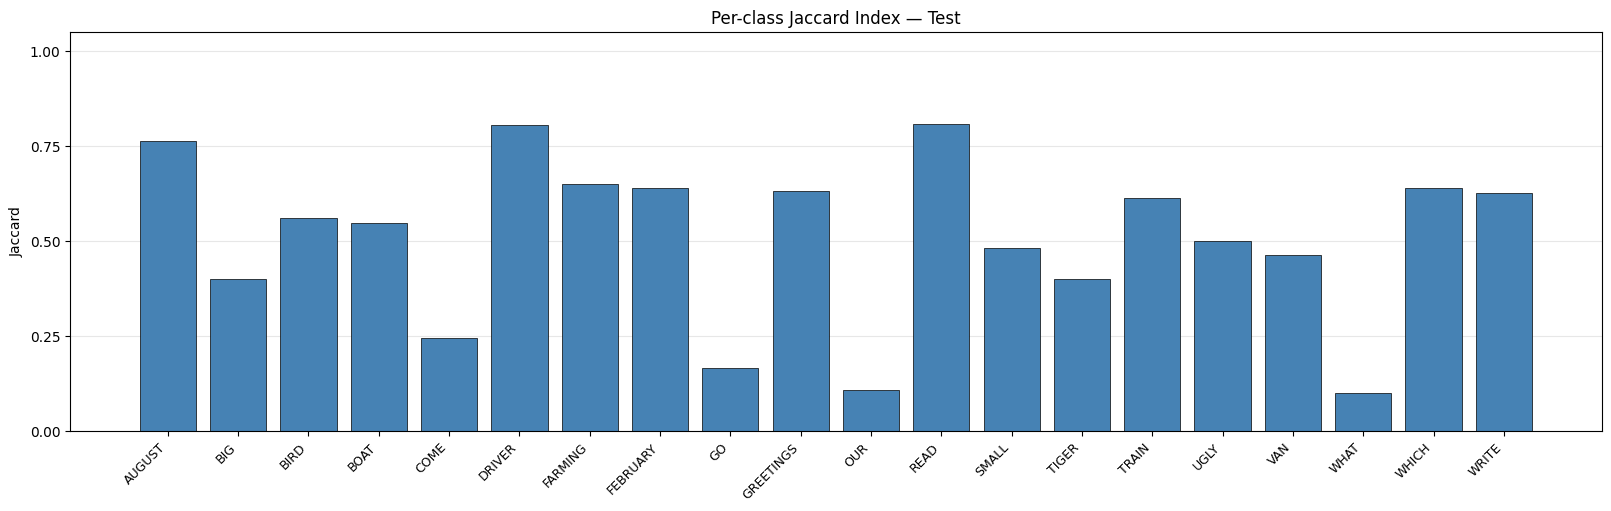

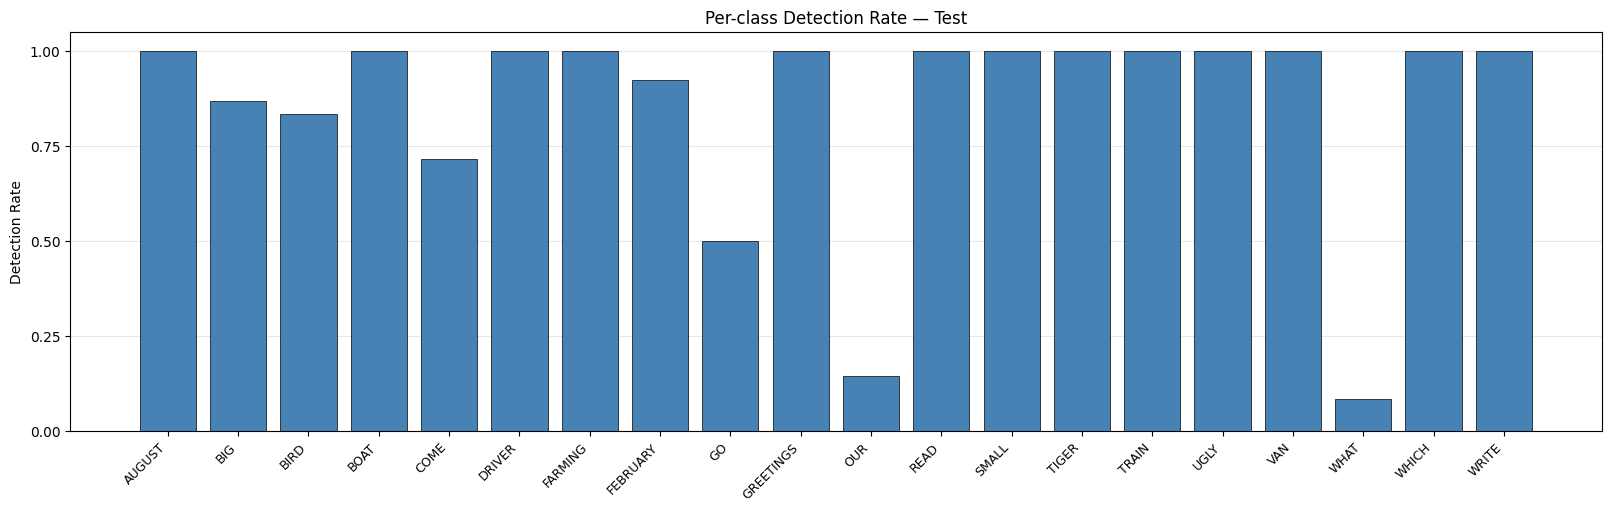

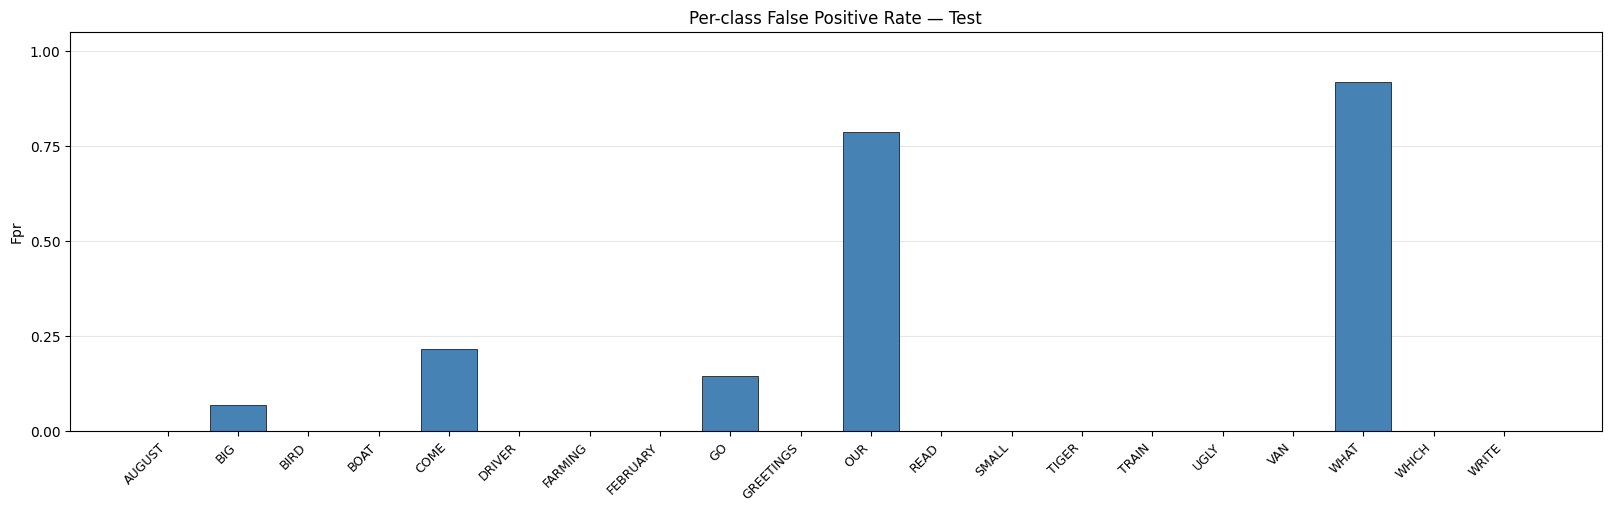

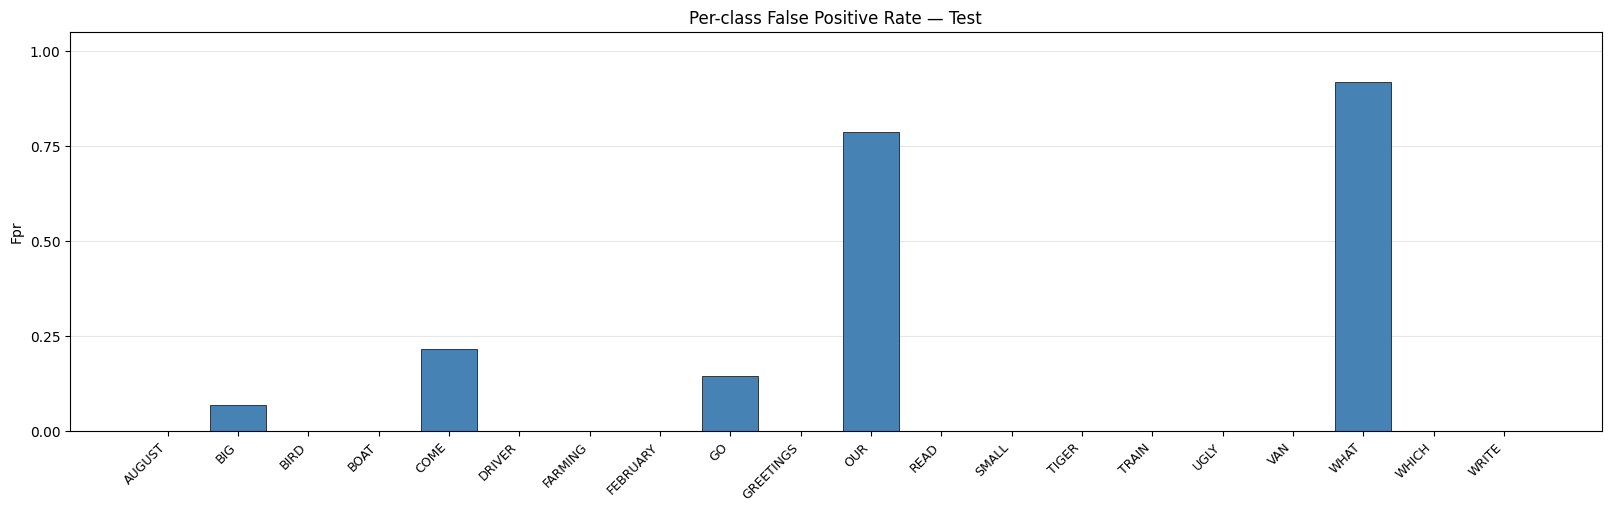

In [27]:
reproduce_streaming_metrics(test_df, test_arrays, "Test")

class_names_no_bg = [id_to_label[i] for i in range(len(id_to_label) - 1)]
per_class_test = get_per_class_metrics_df(class_names=class_names_no_bg)

plot_per_class_metric_bar(per_class_test, metric="jaccard",
                           title="Per-class Jaccard Index — Test")
plot_per_class_metric_bar(per_class_test, metric="detection_rate",
                           title="Per-class Detection Rate — Test")
plot_per_class_metric_bar(per_class_test, metric="fpr",
                           title="Per-class False Positive Rate — Test")

---
## Decoder Experiments — bag_size and bg_exit_frames

Two experiments on top of the baseline (`bag_size=5`, `bg_exit_frames=1` — the current
defaults, immediate exit to SEEKING on a single background frame):

1. **`bag_size=1`** — no bag averaging at all; the decoder gates directly on each raw
   window's softmax probs instead of averaging 5 windows first.
2. **`bg_exit_frames=2`** — require 2 *consecutive* background-gated frames before leaving
   `IN_SIGN`, instead of exiting immediately on the first one.

Both run against the currently-loaded `test_df`/`val_df` (user2).

In [28]:
def summarize_global_results() -> dict:
    """Macro-averaged DR / MR / FPR / Jaccard from the current global accumulators
    (same computation as print_global_results, returned as a dict for comparison)."""
    total_tp, total_gt, total_fp, total_misc = 0, 0, 0, 0
    all_jac = []
    for i in range(num_classes):
        gt, fp = _global_total_gestures[i], _global_false_positives[i]
        if gt == 0 and fp == 0:
            continue
        miss, misc = _global_missed[i], _global_misclassified[i]
        j_sum, j_cnt = _global_jaccard_sum[i], _global_jaccard_counts[i]
        jac_denom = j_cnt + miss + misc + fp
        all_jac.append(j_sum / jac_denom if jac_denom > 0 else 0.0)
        total_tp += _global_correct_predictions[i]
        total_gt += gt
        total_fp += fp
        total_misc += misc

    return {
        "detection_rate": total_tp / total_gt if total_gt else 0.0,
        "misclass_rate":  total_misc / total_gt if total_gt else 0.0,
        "fpr":            total_fp / total_gt if total_gt else 0.0,
        "jaccard":        sum(all_jac) / len(all_jac) if all_jac else float("nan"),
    }


def evaluate_decoder_variant(df: pd.DataFrame, arrays: dict, split_label: str,
                              verbose: bool = True, **decoder_kwargs) -> dict:
    """
    Replay the decoder over every sequence in `df` with the given decoder_kwargs
    override (e.g. bag_size=1, bg_exit_frames=2), accumulating both mean WER and
    SHREC\'21 streaming metrics in one pass. Returns a summary dict.
    """
    n_classes   = len(id_to_label) - 1  # exclude background
    class_names = [id_to_label[i] for i in range(n_classes)]
    initialize_globals(n_classes=n_classes)

    wers = []
    for _, row in df.iterrows():
        stream_steps, emitted_preds, emit_regions = replay_decoder_from_logits(
            row, arrays, **decoder_kwargs
        )
        gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
        wers.append(compute_wer(emitted_preds, gt))

        frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
            _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
        evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

    summary = summarize_global_results()
    summary["mean_wer"] = float(np.mean(wers))

    if verbose:
        print(f"\n===== {split_label} =====")
        print_global_results(class_names=class_names)
        print(f"Mean WER: {summary['mean_wer']:.4f}")

    return summary


### Baseline (bag_size=5, bg_exit_frames=1)

In [29]:
baseline_test = evaluate_decoder_variant(test_df, test_arrays, "Baseline - Test", verbose=False)
baseline_val  = evaluate_decoder_variant(val_df,  val_arrays,  "Baseline - Val",  verbose=False)
print("Baseline Test:", baseline_test)
print("Baseline Val: ", baseline_val)


Baseline Test: {'detection_rate': 0.8539325842696629, 'misclass_rate': 0.03745318352059925, 'fpr': 0.10486891385767791, 'jaccard': 0.5064662902786039, 'mean_wer': 0.04452054794520548}
Baseline Val:  {'detection_rate': 0.9666666666666667, 'misclass_rate': 0.0, 'fpr': 0.041666666666666664, 'jaccard': 0.58771961116587, 'mean_wer': 0.0101010101010101}


### Experiment 1 — bag_size = 1 (no bag averaging)

In [30]:
exp_bagsize1_test = evaluate_decoder_variant(test_df, test_arrays, "bag_size=1 - Test",
                                              bag_size=1, verbose=False)
exp_bagsize1_val  = evaluate_decoder_variant(val_df,  val_arrays,  "bag_size=1 - Val",
                                              bag_size=1, verbose=False)

bagsize_comparison = pd.DataFrame({
    "baseline_test": baseline_test, "bag_size=1_test": exp_bagsize1_test,
    "baseline_val":  baseline_val,  "bag_size=1_val":  exp_bagsize1_val,
}).T
bagsize_comparison


,detection_rate,misclass_rate,fpr,jaccard,mean_wer
baseline_test,0.853933,0.037453,0.104869,0.506466,0.044521
bag_size=1_test,0.891386,0.041199,0.071161,0.538027,0.049087
baseline_val,0.966667,0.000000,0.041667,0.587720,0.010101
bag_size=1_val,0.983333,0.000000,0.025000,0.627506,0.010101


### Experiment 2 — bg_exit_frames = 2

Requires 2 consecutive background-gated frames (instead of 1) before the decoder leaves `IN_SIGN`, so a single-frame background blip inside a sign no longer ends it immediately.

In [31]:
exp_bgexit2_test = evaluate_decoder_variant(test_df, test_arrays, "bg_exit_frames=2 - Test",
                                             bg_exit_frames=2, verbose=False)
exp_bgexit2_val  = evaluate_decoder_variant(val_df,  val_arrays,  "bg_exit_frames=2 - Val",
                                             bg_exit_frames=2, verbose=False)

full_comparison = pd.DataFrame({
    "baseline_test":       baseline_test,
    "bag_size=1_test":     exp_bagsize1_test,
    "bg_exit_frames=2_test": exp_bgexit2_test,
    "baseline_val":        baseline_val,
    "bag_size=1_val":      exp_bagsize1_val,
    "bg_exit_frames=2_val": exp_bgexit2_val,
}).T
full_comparison


,detection_rate,misclass_rate,fpr,jaccard,mean_wer
baseline_test,0.853933,0.037453,0.104869,0.506466,0.044521
bag_size=1_test,0.891386,0.041199,0.071161,0.538027,0.049087
bg_exit_frames=2_test,0.861423,0.037453,0.101124,0.501212,0.044521
baseline_val,0.966667,0.000000,0.041667,0.587720,0.010101
bag_size=1_val,0.983333,0.000000,0.025000,0.627506,0.010101
bg_exit_frames=2_val,0.966667,0.000000,0.041667,0.582583,0.010101


---
## Multi-User Validation — bag_size and bg_exit_frames

The experiments above only used `user2`. Load `user1`, `user2`, `user3`, `user5` (test + val)
and re-run the same three decoder variants (baseline, bag_size=1, bg_exit_frames=2) — per-user
and pooled across all users — to check whether bag_size=1's win generalizes, or whether it's
specific to user2 (as flagged above re: thresholds being tuned around a bagged/smoothed signal).

In [32]:
ALL_USERS   = ["user1", "user2", "user3", "user5"]
SPLIT_STAMP = "20260706t152636z"

all_splits = {}
for u in ALL_USERS:
    t_df, t_arr = load_split_results(f"test_{u}_{SPLIT_STAMP}")
    v_df, v_arr = load_split_results(f"val_{u}_{SPLIT_STAMP}")
    all_splits[u] = {"test": (t_df, t_arr), "val": (v_df, v_arr)}
    print(f"{u}: test={len(t_df):>2} seqs (mean WER={t_df['wer'].mean():.3f}), "
          f"val={len(v_df):>2} seqs (mean WER={v_df['wer'].mean():.3f})")


test_user1_20260706t152636z


FileNotFoundError: [Errno 2] No such file or directory: './trained_models42/results\\test_user1_20260706t152636z_metadata.parquet'

In [ ]:
MULTIUSER_DECODER_VARIANTS = {
    "baseline":                     {},
    "bag_size=1":                   {"bag_size": 1},
    "bg_exit_frames=2":             {"bg_exit_frames": 2},
    "bag_size=1+bg_exit_frames=2":  {"bag_size": 1, "bg_exit_frames": 2},
}


def evaluate_decoder_variant_pooled(all_splits: dict, split_name: str, variant_label: str,
                                     verbose: bool = True, **decoder_kwargs) -> dict:
    """
    Same as evaluate_decoder_variant, but pools every user\'s `split_name` (test/val)
    sequences into one set of global accumulators — gives one pooled verdict per
    variant instead of per-user numbers.
    """
    n_classes   = len(id_to_label) - 1
    class_names = [id_to_label[i] for i in range(n_classes)]
    initialize_globals(n_classes=n_classes)

    wers       = []
    total_seqs = 0
    for u, splits in all_splits.items():
        df, arrays = splits[split_name]
        total_seqs += len(df)
        for _, row in df.iterrows():
            stream_steps, emitted_preds, emit_regions = replay_decoder_from_logits(
                row, arrays, **decoder_kwargs
            )
            gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
            wers.append(compute_wer(emitted_preds, gt))

            frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
                _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
            evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

    summary = summarize_global_results()
    summary["mean_wer"]      = float(np.mean(wers))
    summary["num_sequences"] = total_seqs

    if verbose:
        print(f"\n===== {variant_label} — {split_name} (pooled across {list(all_splits.keys())}) =====")
        print_global_results(class_names=class_names)
        print(f"Mean WER: {summary['mean_wer']:.4f}  (n={total_seqs})")

    return summary


### Per-user, per-variant results

In [ ]:
per_user_records = []
for u in ALL_USERS:
    for split_name in ["test", "val"]:
        df, arrays = all_splits[u][split_name]
        for variant_name, kwargs in MULTIUSER_DECODER_VARIANTS.items():
            summary = evaluate_decoder_variant(
                df, arrays, f"{u}-{split_name}-{variant_name}", verbose=False, **kwargs
            )
            summary.update({"user": u, "split": split_name, "variant": variant_name,
                             "num_sequences": len(df)})
            per_user_records.append(summary)

multiuser_bagsize_results = pd.DataFrame(per_user_records)[
    ["user", "split", "variant", "num_sequences",
     "detection_rate", "misclass_rate", "fpr", "jaccard", "mean_wer"]
]
multiuser_bagsize_results


### Pooled verdict — all users combined, per split

In [ ]:
pooled_records = []
for split_name in ["test", "val"]:
    for variant_name, kwargs in MULTIUSER_DECODER_VARIANTS.items():
        summary = evaluate_decoder_variant_pooled(
            all_splits, split_name, f"{split_name}-{variant_name}", verbose=False, **kwargs
        )
        summary.update({"split": split_name, "variant": variant_name})
        pooled_records.append(summary)

pooled_bagsize_comparison = pd.DataFrame(pooled_records)[
    ["split", "variant", "num_sequences", "detection_rate", "misclass_rate", "fpr", "jaccard", "mean_wer"]
].set_index(["split", "variant"])
pooled_bagsize_comparison


### Verdict

Pooled across all 4 users (test = 276 sequences, val = 132 sequences):

| split | variant | detection_rate | misclass_rate | fpr | jaccard | mean_wer |
|---|---|---|---|---|---|---|
| test | baseline | 0.893 | 0.029 | 0.136 | 0.484 | 0.109 |
| test | bag_size=1 | 0.912 | 0.031 | 0.116 | 0.518 | 0.111 |
| test | bg_exit_frames=2 | 0.897 | 0.030 | 0.123 | 0.485 | 0.103 |
| test | **bag_size=1 + bg_exit_frames=2** | **0.916** | 0.031 | **0.104** | **0.523** | 0.105 |
| val | baseline | 0.940 | 0.000 | 0.067 | 0.564 | 0.007 |
| val | bag_size=1 | 0.960 | 0.000 | 0.046 | 0.606 | 0.007 |
| val | bg_exit_frames=2 | 0.942 | 0.000 | 0.063 | 0.561 | 0.005 |
| val | **bag_size=1 + bg_exit_frames=2** | **0.963** | 0.000 | **0.042** | 0.602 | **0.005** |

**The combined variant is the best (or tied-best) configuration on almost every metric,
on both splits.** It picks up `bag_size=1`'s detection-rate/FPR/Jaccard gains *and*
`bg_exit_frames=2`'s WER gain simultaneously — the two changes don't fight each other or
cancel out, they stack. Test FPR in particular improves the most of any single change
(0.136→0.104, a bigger drop than either change alone), and val detection rate hits its
highest point across all four variants (0.963).

bag_size=1 generalizes — it isn't a user2-specific artifact. Per-user, it improves
detection rate, FPR, and Jaccard for every single one of the 4 users on both test and val
(e.g. user5 test FPR 0.065→0.038, user1 val Jaccard 0.551→0.604), at the cost of a small
WER increase for user1/user3 test (0.274→0.286, 0.073→0.077) offset by a WER improvement
for user5 (0.035→0.028).

This still doesn't fully separate "no bag averaging helps" from "the existing thresholds
happen to suit a peakier, un-averaged signal better" (see the note above about
`CONFIDENCE_THRESHOLD`/`SIGN_BG_MARGIN` being applied to whatever signal shape `bag_size`
produces) — but the fact that it holds up independently across 4 different users' data,
and combines cleanly with an unrelated change (`bg_exit_frames`), is a much stronger signal
than the single-user result alone.

**Overall: adopt bag_size=1 + bg_exit_frames=2 together.** It's the strongest and most
broadly validated configuration of everything tested so far. Re-tuning
`CONFIDENCE_THRESHOLD`/`SIGN_BG_MARGIN` specifically for `bag_size=1` would still be worth
doing to check whether the gain grows further once thresholds aren't inherited from the
old bag_size=5 setup.

---
## Combined Multi-Seed, Multi-User Evaluation — Extended Decoder Grid

Everything above used only `trained_models42` (one training seed). This section combines
**both** `trained_models42` and `trained_models43` (two independent training seeds) — all
4 users, both splits, all pooled into one set of numbers per variant — plus a fuller grid
of decoder combinations, adding `sign_bg_margin=0` (no separation margin required between
the top sign class and background) on top of `bag_size` and `bg_exit_frames`.

`sign_bg_margin=0` means a frame counts as a sign whenever its top-1 probability alone
clears `CONFIDENCE_THRESHOLD`, even if the background probability is almost as high —
i.e. it removes the "how much more confident is the sign than background" check entirely,
keeping only the absolute confidence check.

In [ ]:
RUN_RESULTS_DIRS = {
    "seed42": "./trained_models42/results",
    "seed43": "./trained_models43/results",
}
RUN_SPLIT_STAMPS = {
    "seed42": "20260706t152636z",
    "seed43": "20260706t152926z",
}

all_runs = {}
for run_name, results_dir in RUN_RESULTS_DIRS.items():
    stamp = RUN_SPLIT_STAMPS[run_name]
    all_runs[run_name] = {}
    for u in ALL_USERS:
        t_df, t_arr = load_split_results(f"test_{u}_{stamp}", results_dir=results_dir)
        v_df, v_arr = load_split_results(f"val_{u}_{stamp}",  results_dir=results_dir)
        all_runs[run_name][u] = {"test": (t_df, t_arr), "val": (v_df, v_arr)}
        print(f"{run_name}/{u}: test={len(t_df):>2} seqs (mean WER={t_df['wer'].mean():.3f}), "
              f"val={len(v_df):>2} seqs (mean WER={v_df['wer'].mean():.3f})")


In [ ]:
# Full factorial grid: bag_size in {5 (default), 1}, bg_exit_frames in {1 (default), 2},
# sign_bg_margin in {0.10 (default), 0.0} -> 8 combinations.
DECODER_GRID = {
    "baseline":                                     {},
    "bag_size=1":                                   {"bag_size": 1},
    "bg_exit_frames=2":                             {"bg_exit_frames": 2},
    "sign_bg_margin=0":                              {"sign_bg_margin": 0.0},
    "bag_size=1+bg_exit_frames=2":                   {"bag_size": 1, "bg_exit_frames": 2},
    "bag_size=1+sign_bg_margin=0":                    {"bag_size": 1, "sign_bg_margin": 0.0},
    "bg_exit_frames=2+sign_bg_margin=0":              {"bg_exit_frames": 2, "sign_bg_margin": 0.0},
    "bag_size=1+bg_exit_frames=2+sign_bg_margin=0":   {"bag_size": 1, "bg_exit_frames": 2, "sign_bg_margin": 0.0},
}


def evaluate_decoder_variant_grand_pooled(all_runs: dict, split_name: str, variant_label: str,
                                           verbose: bool = True, **decoder_kwargs) -> dict:
    """
    Pools every (seed, user) combination\'s `split_name` (test/val) sequences into ONE set
    of global accumulators — the combined result across both training seeds and all 4 users
    for a single decoder variant.
    """
    n_classes   = len(id_to_label) - 1
    class_names = [id_to_label[i] for i in range(n_classes)]
    initialize_globals(n_classes=n_classes)

    wers       = []
    total_seqs = 0
    for run_name, per_user in all_runs.items():
        for u, splits in per_user.items():
            df, arrays = splits[split_name]
            total_seqs += len(df)
            for _, row in df.iterrows():
                stream_steps, emitted_preds, emit_regions = replay_decoder_from_logits(
                    row, arrays, **decoder_kwargs
                )
                gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
                wers.append(compute_wer(emitted_preds, gt))

                frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
                    _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
                evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

    summary = summarize_global_results()
    summary["mean_wer"]      = float(np.mean(wers))
    summary["num_sequences"] = total_seqs

    if verbose:
        print(f"\n===== {variant_label} — {split_name} "
              f"(pooled across {list(all_runs.keys())} x {list(next(iter(all_runs.values())).keys())}) =====")
        print_global_results(class_names=class_names)
        print(f"Mean WER: {summary['mean_wer']:.4f}  (n={total_seqs})")

    return summary


### Combined result — both seeds, all 4 users, full decoder grid

In [ ]:
grand_records = []
for split_name in ["test", "val"]:
    for variant_name, kwargs in DECODER_GRID.items():
        summary = evaluate_decoder_variant_grand_pooled(
            all_runs, split_name, f"{split_name}-{variant_name}", verbose=False, **kwargs
        )
        summary.update({"split": split_name, "variant": variant_name})
        grand_records.append(summary)

grand_grid_comparison = pd.DataFrame(grand_records)[
    ["split", "variant", "num_sequences", "detection_rate", "misclass_rate", "fpr", "jaccard", "mean_wer"]
].set_index(["split", "variant"])
grand_grid_comparison


### Verdict

Combined across **both training seeds** (trained_models42 + trained_models43) and all 4
users (test = 552 sequences, val = 264 sequences):

| split | variant | detection_rate | misclass_rate | fpr | jaccard | mean_wer |
|---|---|---|---|---|---|---|
| test | baseline | 0.878 | 0.038 | 0.133 | 0.474 | 0.106 |
| test | bag_size=1 | 0.899 | 0.040 | 0.113 | 0.511 | 0.110 |
| test | bg_exit_frames=2 | 0.882 | 0.040 | 0.120 | 0.474 | **0.100** |
| test | sign_bg_margin=0 | 0.882 | 0.039 | 0.129 | 0.476 | 0.107 |
| test | bag_size=1+bg_exit_frames=2 | 0.904 | 0.044 | 0.096 | 0.515 | 0.101 |
| test | bag_size=1+sign_bg_margin=0 | 0.900 | 0.041 | 0.113 | 0.511 | 0.113 |
| test | bg_exit_frames=2+sign_bg_margin=0 | 0.887 | 0.042 | 0.114 | 0.478 | 0.102 |
| test | **all three combined** | **0.906** | 0.045 | **0.093** | **0.518** | 0.103 |
| val | baseline | 0.954 | 0.000 | 0.048 | 0.577 | 0.0022 |
| val | bag_size=1 | 0.974 | 0.000 | 0.028 | **0.620** | 0.0019 |
| val | bg_exit_frames=2 | 0.954 | 0.000 | 0.047 | 0.572 | **0.0009** |
| val | sign_bg_margin=0 | 0.957 | 0.000 | 0.045 | 0.579 | 0.0022 |
| val | bag_size=1+bg_exit_frames=2 | 0.974 | 0.000 | 0.028 | 0.614 | 0.0019 |
| val | bag_size=1+sign_bg_margin=0 | 0.974 | 0.000 | 0.029 | 0.620 | 0.0032 |
| val | bg_exit_frames=2+sign_bg_margin=0 | 0.957 | 0.000 | 0.044 | 0.574 | 0.0009 |
| val | **all three combined** | **0.974** | 0.000 | 0.028 | 0.615 | 0.0019 |

**`sign_bg_margin=0` alone is the weakest of the three individual changes** — a small,
real improvement on test (DR 0.878→0.882, FPR 0.133→0.129) but it barely moves val at all
(val already has near-zero misclassification/FPR, so there's little room for a
margin-relaxation to help). It never hurts, though — every combination that includes it is
still at or above the corresponding combination without it.

**All three combined is the best test-set configuration overall** — highest detection
rate (0.906), lowest FPR (0.093), highest Jaccard (0.518) of all 8 variants tested. Its WER
(0.103) isn't quite the single best (bg_exit_frames=2 alone gets 0.100, and
bag_size=1+bg_exit_frames=2 gets 0.101), but it's close, and it dominates on every other
metric — a reasonable trade to make if FPR/detection rate matter more than shaving another
0.002 off WER.

**On val, bag_size=1 (with or without the other two) is essentially tied for best** —
sign_bg_margin=0 and bg_exit_frames=2 contribute little there since val is already close to
ceiling (0 misclassification, very low FPR), so there's less headroom for them to show an
effect; test is the more informative split for comparing these variants.

**This is now validated across 2 independent training seeds × 4 users (8 independent
data sources total)** — the strongest generalization check run so far. bag_size=1 remains
the single highest-impact change; the full three-way combination is the best all-around
default if you want one configuration to standardize on.

Still open: re-tuning `CONFIDENCE_THRESHOLD` specifically for `bag_size=1` (see the earlier
note on thresholds being inherited from the bag_size=5 setup) to check whether any of these
gains grow further once the threshold isn't a hand-me-down from the old configuration.

---
## Dataset Sign-Length Check

Loads the raw dataset the same way `main.py` does for training
(`data_loading.load_all_segments(DATASET_ROOT)`), then measures how short the
shortest annotated sign actually is — useful for sanity-checking
`MIN_SIGN_FRAMES` (currently the decoder discards any emitted region shorter
than that many frames as noise).

**Note:** unlike the ported decoder/metrics code above, this section imports
`config`/`data_loading` directly (not copied in) since it's just the standard
training-time data loading, not something we're tweaking — but `config.py`
imports `torch`, so this section needs a kernel with torch installed
(e.g. `pytorch_gpu`), not the plotting-only environment the rest of this
notebook can run under.

In [35]:
"""
Central configuration for the THCT-Net sign-language recognition pipeline.

All hyperparameters, paths, device setup, feature definitions, and
reproducibility seeding live here. Every other module imports from config.
"""
from __future__ import annotations

import random
from pathlib import Path

import numpy as np

SEED = 42
# ──────────────────────────────────────────────────────────────────────
# Label / split constants
# ──────────────────────────────────────────────────────────────────────
BACKGROUND_LABEL = "background"

# All users available in the dataset (used by leave-one-out).
ALL_USERS = ["user1", "user2", "user3", "user5"]

# Default users for single-split mode (override via CLI / main).
DEFAULT_DEV_USERS = ["user1", "user2", "user5"]
DEFAULT_TEST_USER = "user3"
DEV_VAL_RATIO = 0.12
DEV_VAL_SEED = SEED + 202

# ──────────────────────────────────────────────────────────────────────
# Training hyperparameters
# ──────────────────────────────────────────────────────────────────────
BATCH_SIZE = 4
GLOSS_BALANCED_GLOSSES_PER_BATCH = 4
GLOSS_BALANCED_SAMPLES_PER_GLOSS = 6
MODEL_NAME = "thct_net"
NORMALIZATION_NAME = "palm_ref"
EPOCHS = 7
LEARNING_RATE = 3e-4

# ──────────────────────────────────────────────────────────────────────
# Data Augmentation Configuration
# ──────────────────────────────────────────────────────────────────────
USE_AUGMENTATION = False
AUGMENT_ROTATION_PROB = 0.5
AUGMENT_ROTATION_RANGE = 8.0     # degrees (±8 deg)
AUGMENT_SCALING_PROB = 0.5
AUGMENT_SCALING_RANGE = (0.95, 1.05)
AUGMENT_NOISE_PROB = 0.5
AUGMENT_NOISE_STD = 2.0          # mm (since relative coordinates are in mm)
AUGMENT_DROPOUT_PROB = 0.0
AUGMENT_DROPOUT_RATE = 0.00


# ──────────────────────────────────────────────────────────────────────
# THCT-Net architecture
# ──────────────────────────────────────────────────────────────────────
D_MODEL = 128          # Transformer hidden dimension
NUM_HEADS = 4          # Attention heads
NUM_TRANSFORMER_LAYERS = 4   # Number of ISATA blocks
BASE_CH = 64           # CNN base channels
DROPOUT = 0.1          # Dropout rate (used in Transformer stream)

WINDOW_SIZE = 30
STRIDE = 1

# ──────────────────────────────────────────────────────────────────────
# Streaming / online decoder
# ──────────────────────────────────────────────────────────────────────
STREAM_MODE = "thct_net_batch"
WER_EXAMPLE_PRINT_COUNT = 5

LEAP_FPS = 30
MIN_SIGN_MS = 500
MIN_SIGN_FRAMES = max(1, int(round((MIN_SIGN_MS / 1000.0) * LEAP_FPS)))

BAG_SIZE = 5
BAG_AGGREGATION = "mean"
CONFIDENCE_THRESHOLD = 0.35
SIGN_BG_MARGIN = 0.10

ONLINE_WINDOW_SIZE = WINDOW_SIZE
ONLINE_STRIDE = 1

# ──────────────────────────────────────────────────────────────────────
# Feature definition (132 raw Leap features)
# ──────────────────────────────────────────────────────────────────────
HANDS = ["left", "right"]
FINGERS = ["thumb", "index", "middle", "ring", "pinky"]
BONES = ["metacarpal", "proximal", "intermediate", "distal"]
CARTESIAN_AXES = ["x", "y", "z"]
START_AXES = ["sx", "sy", "sz"]

FEATURE_KEYS: list[str] = []

# Palm and wrist coordinates per hand.
for _hand in HANDS:
    for _part in ["palm", "wrist"]:
        for _axis in CARTESIAN_AXES:
            FEATURE_KEYS.append(f"{_hand}_{_part}_{_axis}")

# Finger bone start-joint coordinates per hand.
for _hand in HANDS:
    for _finger in FINGERS:
        for _bone in BONES:
            for _axis in START_AXES:
                FEATURE_KEYS.append(f"{_hand}_{_finger}_{_bone}_{_axis}")

assert len(FEATURE_KEYS) == 132, f"Expected 132 features, got {len(FEATURE_KEYS)}"

INPUT_DIM = len(FEATURE_KEYS)

FEATURE_INDEX = {key: idx for idx, key in enumerate(FEATURE_KEYS)}

PALM_TRIPLETS: dict[str, tuple[int, int, int]] = {}
HAND_POSITION_TRIPLETS: dict[str, list[tuple[int, int, int]]] = {}

for _hand in HANDS:
    PALM_TRIPLETS[_hand] = tuple(
        FEATURE_INDEX[f"{_hand}_palm_{axis}"] for axis in CARTESIAN_AXES
    )

    _triplets: list[tuple[int, int, int]] = []
    _triplets.append(
        tuple(FEATURE_INDEX[f"{_hand}_wrist_{axis}"] for axis in CARTESIAN_AXES)
    )
    for _finger in FINGERS:
        for _bone in BONES:
            _triplets.append(
                tuple(FEATURE_INDEX[f"{_hand}_{_finger}_{_bone}_{_axis}"] for _axis in START_AXES)
            )
    HAND_POSITION_TRIPLETS[_hand] = _triplets



"""
Data loading: CSV/TXT parsing, recording discovery, and segment extraction.

Provides:
  - load_segments           : parse annotation TXT file
  - load_leap_csv           : parse Leap CSV → (T, 132) feature matrix
  - find_user_recordings    : discover matching CSV+TXT pairs per user
  - build_intervals_with_background : insert background gaps between signs
  - extract_segments_for_recording  : build per-interval records for one recording
  - load_all_segments       : full pipeline → segments_by_user dict
"""
from __future__ import annotations

import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


"""
Feature extraction and normalization for Leap Motion skeleton data.

Provides:
  - extract_features_from_row : CSV row → 132-D raw feature vector
  - palm_reference_normalize_frame : per-frame palm-reference normalization
  - palm_reference_normalize_sequence : vectorised version for (T, D) arrays
"""
from __future__ import annotations

import numpy as np
import pandas as pd



# ──────────────────────────────────────────────────────────────────────
# Helpers
# ──────────────────────────────────────────────────────────────────────

def _safe_float(value, default: float = 0.0) -> float:
    """Convert values to float safely; return default on invalid input."""
    try:
        if pd.isna(value):
            return default
        return float(value)
    except Exception:
        return default


# ──────────────────────────────────────────────────────────────────────
# Raw feature extraction
# ──────────────────────────────────────────────────────────────────────

def extract_features_from_row(row: pd.Series) -> np.ndarray:
    """Convert one Leap CSV row to one 132-D raw feature frame (no normalization)."""
    values = np.asarray(
        [_safe_float(row.get(key, 0.0)) for key in FEATURE_KEYS],
        dtype=np.float32,
    )
    return np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0).astype(
        np.float32, copy=False
    )


# ──────────────────────────────────────────────────────────────────────
# Palm-reference normalization
# ──────────────────────────────────────────────────────────────────────

def palm_reference_normalize_frame(frame: np.ndarray) -> np.ndarray:
    """Normalize one frame by subtracting each hand's palm from that hand's coordinates.

    Input shape: (132,)
    Output shape: (132,)
    """
    out = np.asarray(frame, dtype=np.float32).copy()
    if out.shape[0] != len(FEATURE_KEYS):
        raise ValueError(
            f"Expected frame with {len(FEATURE_KEYS)} features, got {out.shape[0]}"
        )

    for hand in HANDS:
        px, py, pz = PALM_TRIPLETS[hand]
        palm = out[[px, py, pz]].copy()
        if not np.all(np.isfinite(palm)):
            palm = np.zeros((3,), dtype=np.float32)

        for ix, iy, iz in HAND_POSITION_TRIPLETS[hand]:
            out[ix] = out[ix] - palm[0]
            out[iy] = out[iy] - palm[1]
            out[iz] = out[iz] - palm[2]

        # Keep palm channels for stable shape and explicit origin anchoring.
        out[px] = 0.0
        out[py] = 0.0
        out[pz] = 0.0

    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(
        np.float32, copy=False
    )


def palm_reference_normalize_sequence(sequence: np.ndarray) -> np.ndarray:
    """Apply palm-reference normalization frame-wise.

    Input shape: (T, D)
    Output shape: (T, D)
    """
    seq = np.asarray(sequence, dtype=np.float32)
    if seq.ndim != 2:
        raise ValueError(f"Expected sequence with shape (T, D), got {seq.shape}")
    if seq.shape[0] == 0:
        return seq.astype(np.float32, copy=False)

    normalized = np.empty_like(seq, dtype=np.float32)
    for i in range(seq.shape[0]):
        normalized[i] = palm_reference_normalize_frame(seq[i])
    return normalized



RECORDING_ID_PATTERN = re.compile(r"(P\d+_S\d+_R\d+)", re.IGNORECASE)


# ──────────────────────────────────────────────────────────────────────
# File loaders
# ──────────────────────────────────────────────────────────────────────

def load_segments(path: Path) -> list[dict]:
    """Load segmentation file into a list of {start, end, label} dicts."""
    path = Path(path)
    if not path.exists():
        return []

    df = pd.read_csv(
        path, sep=r"\s+", header=None,
        names=["start", "end", "label"], engine="python",
    )
    segments = []

    for _, row in df.iterrows():
        try:
            start = int(row["start"])
            end = int(row["end"])
            label = str(row["label"]).strip()
            if label:
                segments.append({"start": start, "end": end, "label": label})
        except Exception:
            continue

    return segments


def load_leap_csv(
    path: Path,
    return_dataframe: bool = False,
):
    """Load Leap CSV and return feature matrix (num_frames, 132)."""
    path = Path(path)
    if not path.exists():
        empty = np.zeros((0, len(FEATURE_KEYS)), dtype=np.float32)
        return (empty, pd.DataFrame()) if return_dataframe else empty

    df = pd.read_csv(path)
    if df.empty:
        empty = np.zeros((0, len(FEATURE_KEYS)), dtype=np.float32)
        return (empty, df) if return_dataframe else empty

    feature_rows = []
    for _, row in tqdm(
        df.iterrows(), total=len(df),
        desc=f"Extracting {path.name}", leave=False,
    ):
        feature_rows.append(extract_features_from_row(row))

    features = np.vstack(feature_rows).astype(np.float32)
    return (features, df) if return_dataframe else features


# ──────────────────────────────────────────────────────────────────────
# Recording discovery
# ──────────────────────────────────────────────────────────────────────

def extract_recording_id(filename: str) -> str | None:
    """Extract canonical recording ID from a CSV or TXT filename."""
    match = RECORDING_ID_PATTERN.search(filename)
    return match.group(1) if match else None


def find_user_recordings(dataset_root: Path) -> dict[str, list[dict]]:
    """Find matching (CSV, segmentation) pairs for each user directory."""
    dataset_root = Path(dataset_root)
    user_map: dict[str, list[dict]] = defaultdict(list)

    for user_dir in sorted(dataset_root.glob("user*")):
        if not user_dir.is_dir():
            continue

        leap_dir = user_dir / "leap_data"
        seg_dir = user_dir / "segmentation"
        if not leap_dir.exists() or not seg_dir.exists():
            continue

        seg_map = {}
        for seg_path in seg_dir.glob("*.txt"):
            recording_id = extract_recording_id(seg_path.name)
            if recording_id is not None:
                seg_map[recording_id] = seg_path

        for csv_path in leap_dir.glob("*.csv"):
            recording_id = extract_recording_id(csv_path.name)
            if recording_id is None:
                continue

            seg_path = seg_map.get(recording_id)
            if seg_path is not None:
                user_map[user_dir.name].append({
                    "recording_id": recording_id,
                    "csv_path": csv_path,
                    "seg_path": seg_path,
                })

    return user_map


# ──────────────────────────────────────────────────────────────────────
# Segment extraction
# ──────────────────────────────────────────────────────────────────────

def build_intervals_with_background(
    segment_defs: list[dict],
    num_frames: int,
    background_label: str = BACKGROUND_LABEL,
) -> list[dict]:
    """Build labeled intervals including background gaps between annotated signs."""
    if num_frames <= 0:
        return []

    cleaned = []
    for seg in segment_defs:
        try:
            start = max(0, int(seg["start"]))
            end = min(num_frames - 1, int(seg["end"]))
            label = str(seg["label"]).strip()
            if end >= start and label:
                cleaned.append({
                    "start": start, "end": end,
                    "label": label, "is_background": False,
                })
        except Exception:
            continue

    cleaned.sort(key=lambda x: (x["start"], x["end"]))
    intervals = []
    prev_end = -1

    for seg in cleaned:
        if seg["start"] > prev_end + 1:
            intervals.append({
                "start": prev_end + 1,
                "end": seg["start"] - 1,
                "label": background_label,
                "is_background": True,
            })

        intervals.append(seg)
        prev_end = max(prev_end, seg["end"])

    if prev_end < num_frames - 1:
        intervals.append({
            "start": prev_end + 1,
            "end": num_frames - 1,
            "label": background_label,
            "is_background": True,
        })

    return intervals


def extract_segments_for_recording(
    csv_path: Path,
    seg_path: Path,
) -> list[dict]:
    """Return per-interval records for one recording, including background gaps."""
    features, raw_df = load_leap_csv(csv_path, return_dataframe=True)
    segment_defs = load_segments(seg_path)

    if features.shape[0] == 0:
        return []

    interval_defs = build_intervals_with_background(
        segment_defs, num_frames=features.shape[0],
    )
    if not interval_defs:
        return []

    confidence_cols = [
        col for col in ["left_confidence", "right_confidence"]
        if col in raw_df.columns
    ]
    records = []

    for seg in interval_defs:
        start = max(0, int(seg["start"]))
        end = min(features.shape[0] - 1, int(seg["end"]))
        if end < start:
            continue

        segment_array = features[start : end + 1]
        if segment_array.size == 0:
            continue

        segment_confidence = None
        if confidence_cols:
            conf_slice = raw_df.loc[start:end, confidence_cols].to_numpy(
                dtype=np.float32,
            )
            if conf_slice.size > 0:
                segment_confidence = np.nanmean(conf_slice, axis=1)

        records.append({
            "segment": segment_array.astype(np.float32),
            "label": seg["label"],
            "confidence": segment_confidence,
            "segment_span": (start, end),
            "recording_features": features,
            "is_background": bool(seg.get("is_background", False)),
        })

    return records


# ──────────────────────────────────────────────────────────────────────
# High-level loader
# ──────────────────────────────────────────────────────────────────────

def load_all_segments(
    dataset_root: Path,
) -> tuple[dict[str, list[dict]], dict[str, list[dict]]]:
    """Discover all recordings and extract segments.

    Returns
    -------
    user_recordings : dict[user_name → list of recording metadata]
    segments_by_user : dict[user_name → list of segment dicts]
    """
    user_recordings = find_user_recordings(dataset_root)
    if not user_recordings:
        raise RuntimeError(
            "No matching Leap CSV and segmentation TXT pairs were found."
        )

    print("Matched recordings per user:")
    for user_name, recs in user_recordings.items():
        print(f"  {user_name}: {len(recs)} recordings")

    segments_by_user: dict[str, list[dict]] = defaultdict(list)
    for user_name, recordings in user_recordings.items():
        for rec in tqdm(recordings, desc=f"Extracting segments for {user_name}"):
            rec_segments = extract_segments_for_recording(
                rec["csv_path"], rec["seg_path"],
            )
            for item in rec_segments:
                item["recording_id"] = rec["recording_id"]
            segments_by_user[user_name].extend(rec_segments)

    total = sum(len(lst) for lst in segments_by_user.values())
    print(f"\nTotal raw segments (sign + background): {total}")

    return user_recordings, segments_by_user


c:\Shoab\ML\environments\pip_env\data_processing\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
import sys
from pathlib import Path as _Path

sys.path.insert(0, str(_Path.cwd()))




DATASET_ROOT = "C:\Shoab\Thesis\Experiments\dataset"

_, segments_by_user = load_all_segments(DATASET_ROOT)


<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
C:\Users\User\AppData\Local\Temp\ipykernel_24448\2845338979.py:9: SyntaxWarning: invalid escape sequence '\S'
  DATASET_ROOT = "C:\Shoab\Thesis\Experiments\dataset"


Matched recordings per user:
  user1: 76 recordings
  user2: 73 recordings
  user3: 55 recordings
  user5: 72 recordings


Extracting segments for user5: 100%|██████████| 72/72 [01:10<00:00,  1.02it/s]



Total raw segments (sign + background): 2293


In [38]:
sign_records = []
for user, segments in segments_by_user.items():
    for seg in segments:
        if seg["is_background"]:
            continue
        start, end = seg["segment_span"]
        sign_records.append({
            "user":          user,
            "recording_id":  seg["recording_id"],
            "label":         seg["label"],
            "start":         start,
            "end":           end,
            "length_frames": end - start + 1,
        })

sign_lengths_df = pd.DataFrame(sign_records)
sign_lengths_df["length_ms"] = sign_lengths_df["length_frames"] / LEAP_FPS * 1000

print(f"Total sign instances (excluding background): {len(sign_lengths_df)}")
print(f"Shortest sign length : {sign_lengths_df['length_frames'].min()} frames "
      f"({sign_lengths_df['length_ms'].min():.1f} ms)")
print(f"Longest  sign length : {sign_lengths_df['length_frames'].max()} frames")
print(f"Mean     sign length : {sign_lengths_df['length_frames'].mean():.1f} frames")
print()

print("10 shortest sign instances:")
print(sign_lengths_df.nsmallest(10, "length_frames")
      [["user", "recording_id", "label", "length_frames", "length_ms"]]
      .to_string(index=False))
print()

print("Shortest instance per class (sorted ascending):")
print(sign_lengths_df.groupby("label")["length_frames"].min().sort_values().to_string())


Total sign instances (excluding background): 1009
Shortest sign length : 16 frames (533.3 ms)
Longest  sign length : 236 frames
Mean     sign length : 77.6 frames

10 shortest sign instances:
 user recording_id label  length_frames  length_ms
user2     P2_S9_R3  WHAT             16 533.333333
user1     P1_S5_R4  WHAT             21 700.000000
user2     P2_S9_R1  WHAT             21 700.000000
user2     P2_S9_R2  WHAT             21 700.000000
user2     P2_S5_R2  WHAT             22 733.333333
user1     P1_S5_R2  WHAT             23 766.666667
user1     P1_S5_R3  WHAT             23 766.666667
user2     P2_S5_R1  WHAT             25 833.333333
user2     P2_S5_R4  WHAT             25 833.333333
user1     P1_S5_R1  WHAT             27 900.000000

Shortest instance per class (sorted ascending):
label
WHAT         16
GO           30
BIG          34
VAN          34
COME         35
UGLY         39
OUR          39
FARMING      40
TIGER        40
BOAT         41
TRAIN        41
BIRD         48


In [46]:
sign_lengths_df[sign_lengths_df['label'] == "WHAT"]['length_frames'].mean()

32.47826086956522

### Top 5 shortest instances per class

In [ ]:
top5_per_class = (
    sign_lengths_df
    .sort_values("length_frames")
    .groupby("label", sort=False)
    .head(5)
    .sort_values(["label", "length_frames"])
)

for label, group in top5_per_class.groupby("label"):
    print(f"{label}:")
    print(group[["user", "recording_id", "length_frames", "length_ms"]]
          .to_string(index=False, header=False))
    print()


AUGUST:
user2 P2_S3_R2 66 2200.000000
user2 P2_S3_R3 70 2333.333333
user2 P2_S3_R1 75 2500.000000
user1 P1_S3_R7 82 2733.333333
user2 P2_S3_R7 85 2833.333333

BIG:
user5 P5_S8_R6 34 1133.333333
user5 P5_S8_R2 39 1300.000000
user5 P5_S8_R4 40 1333.333333
user2 P2_S2_R8 40 1333.333333
user5 P5_S8_R5 45 1500.000000

BIRD:
user5 P5_S5_R2 48 1600.000000
user5 P5_S5_R3 49 1633.333333
user5 P5_S5_R1 51 1700.000000
user5 P5_S5_R4 52 1733.333333
user5 P5_S7_R3 52 1733.333333

BOAT:
user2  P2_S4_R8 41 1366.666667
user2 P2_S10_R6 46 1533.333333
user2 P2_S10_R5 47 1566.666667
user2  P2_S4_R7 48 1600.000000
user5  P5_S4_R6 50 1666.666667

COME:
user2 P2_S7_R5 35 1166.666667
user2 P2_S1_R7 38 1266.666667
user2 P2_S7_R2 39 1300.000000
user2 P2_S7_R6 40 1333.333333
user2 P2_S7_R1 41 1366.666667

DRIVER:
user2 P2_S7_R1 83 2766.666667
user5 P5_S7_R1 89 2966.666667
user3 P3_S7_R1 91 3033.333333
user2 P2_S7_R4 94 3133.333333
user5 P5_S5_R2 95 3166.666667

FARMING:
user5 P5_S2_R2 40 1333.333333
user5 P5_S8